In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')

### only trade when the CPI/unempleyment that is UNEXPECTED

Priced-in Expectations: Markets are forward-looking. If the survey says CPI will be 3.1% and it comes out at 3.1%, the market has likely already adjusted prices for that outcome. There is no "new" information to act on.

In [11]:
# Load and analyze unemployment data
df_unemp = pd.read_csv('cleaned_unemployment_data.csv')
grouped_unemp = df_unemp.groupby('Date')

expected_unemp = 0
unexpected_unemp = 0

for date, group in grouped_unemp:
    actual = group['Actual'].iloc[0]
    surveyed = group['Surveyed'].iloc[0]
    if actual == surveyed:
        expected_unemp += 1
    else:
        unexpected_unemp += 1

print(f"Unemployment: Expected: {expected_unemp}, Unexpected: {unexpected_unemp}")

# Load and analyze CPI data
df_cpi = pd.read_csv('cleaned_cpi_data.csv')
grouped_cpi = df_cpi.groupby('Date')

expected_cpi = 0
unexpected_cpi = 0

for date, group in grouped_cpi:
    actual = group['Actual'].iloc[0]
    surveyed = group['Surveyed'].iloc[0]
    if actual == surveyed:
        expected_cpi += 1
    else:
        unexpected_cpi += 1

print(f"CPI: Expected: {expected_cpi}, Unexpected: {unexpected_cpi}")

Unemployment: Expected: 8, Unexpected: 19
CPI: Expected: 9, Unexpected: 18


In [6]:
def plot_event_data(file_path, event_name):
    """
    Loads data from a CSV, groups by Date, and plots yield behavior.
    """
    if not os.path.exists(file_path):
        print(f"File not found: {file_path}")
        return

    df = pd.read_csv(file_path)
    
    # Ensure Datetime is a datetime object
    df['Datetime'] = pd.to_datetime(df['Datetime'])
    
    # Group by Date
    grouped = df.groupby('Date')
    
    print(f"--- Analyzing {event_name} Data ---")
    print(f"Found {len(grouped)} unique dates.")
    
    for date, group in grouped:
        # Sort by time
        group = group.sort_values('Datetime')
        
        # Get scalar values
        actual = group['Actual'].iloc[0]
        surveyed = group['Surveyed'].iloc[0]
        previous = group['Previous'].iloc[0]
        
        # Determine relationships
        if actual > surveyed:
            survey_rel = "Actual > Surveyed"
        elif actual < surveyed:
            survey_rel = "Actual < Surveyed"
        else:
            survey_rel = "Actual == Surveyed"
            
        if actual > previous:
            prev_rel = "Actual > Previous"
        elif actual < previous:
            prev_rel = "Actual < Previous"
        else:
            prev_rel = "Actual == Previous"
            
        title_text = (f"{event_name} - Date: {date}\n"
                      f"Actual: {actual} | Surveyed: {surveyed} ({survey_rel})\n"
                      f"Previous: {previous} ({prev_rel})")
        
        # Plotting
        plt.figure(figsize=(14, 6))
        
        # Plot 2Y Yield
        plt.plot(group['Datetime'], group['2Y_Yield'], label='2Y Yield', color='blue', linewidth=2)
        
        # Plot 10Y Yield (or 5Y if available)
        if '10Y_Yield' in group.columns:
            plt.plot(group['Datetime'], group['10Y_Yield'], label='10Y Yield', color='red', linewidth=2)
        elif '5Y_Yield' in group.columns:
            plt.plot(group['Datetime'], group['5Y_Yield'], label='5Y Yield', color='green', linewidth=2)
            
        # ---------------------------------------------------------
        # NEW CODE: Add Vertical Lines for 8:30, 8:35, 8:40
        # ---------------------------------------------------------
        # Extract the date object from the first timestamp in the group
        current_day = group['Datetime'].iloc[0].date()
        
        # Create timestamps for the specific times on that day
        # Note: Ensure your data's timezone matches if necessary. 
        # Here we assume data is strictly numerical/datetime without timezone conflict.
        t_release = pd.Timestamp(f"{current_day} 08:30:00")
        t_35 = pd.Timestamp(f"{current_day} 08:35:00")
        t_40 = pd.Timestamp(f"{current_day} 08:40:00")
        
        # Plot vertical lines
        # Release time (Solid or thicker line to distinguish)
        plt.axvline(x=t_release, color='black', linestyle='-', linewidth=1.5, label='Data Release (8:30)')
        
        # Observation windows (Dashed lines)
        plt.axvline(x=t_35, color='gray', linestyle='--', linewidth=1, label='Pricing Check (8:35)')
        plt.axvline(x=t_40, color='gray', linestyle='--', linewidth=1, label='Pricing Check (8:40)')
        # ---------------------------------------------------------
        
        plt.title(title_text, fontsize=14)
        plt.xlabel('Time', fontsize=12)
        plt.ylabel('Yield', fontsize=12)
        plt.legend(fontsize=12)
        plt.grid(True, alpha=0.3)
        
        # Format x-axis
        plt.gcf().autofmt_xdate()
        
        plt.show()
        print("-" * 50)

## Unemployment Data Analysis

--- Analyzing Unemployment Data ---
Found 27 unique dates.


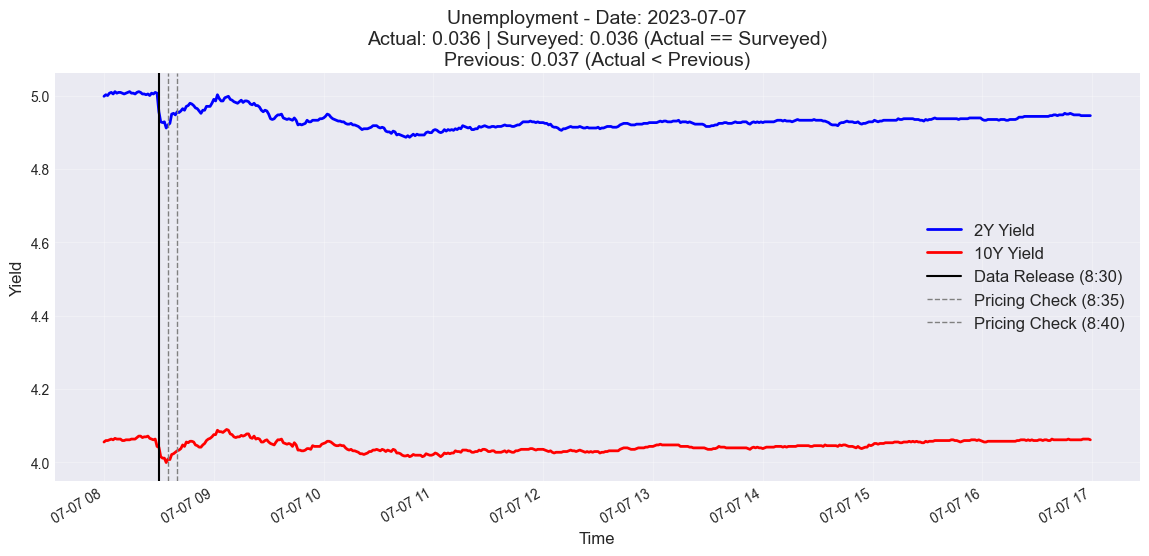

--------------------------------------------------


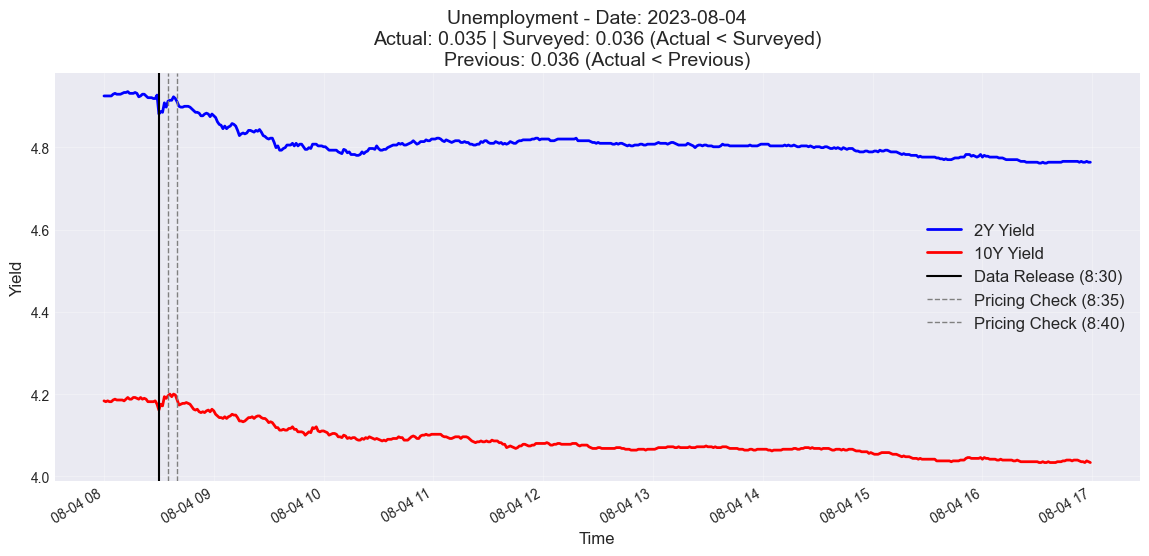

--------------------------------------------------


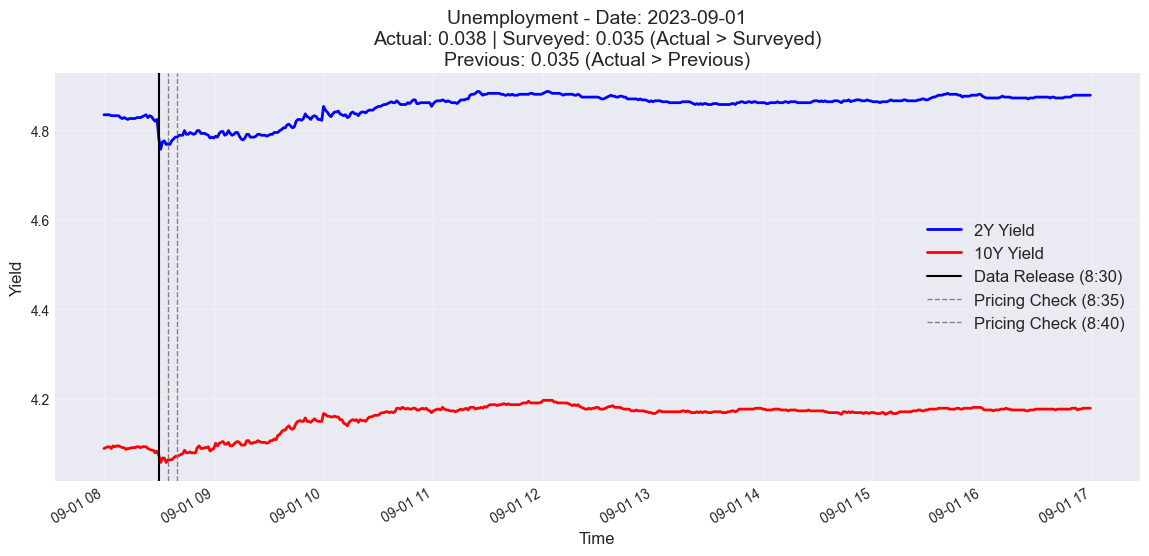

--------------------------------------------------


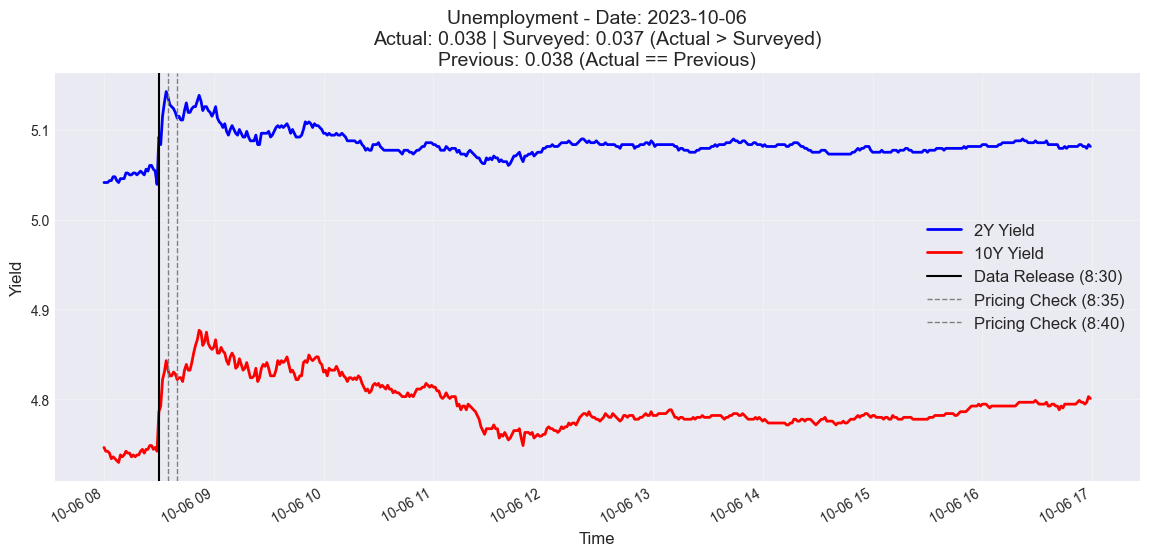

--------------------------------------------------


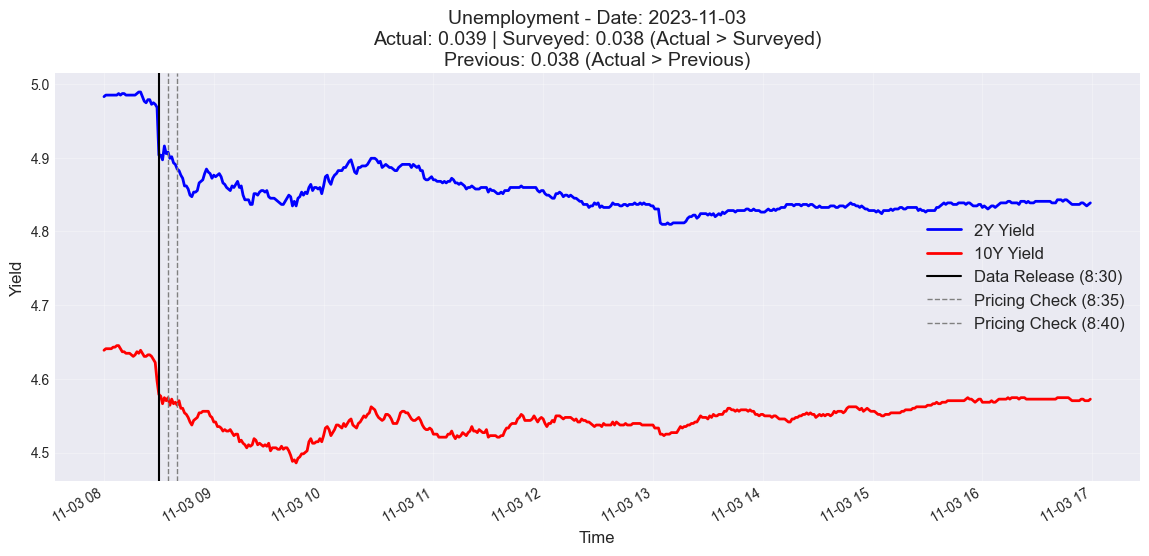

--------------------------------------------------


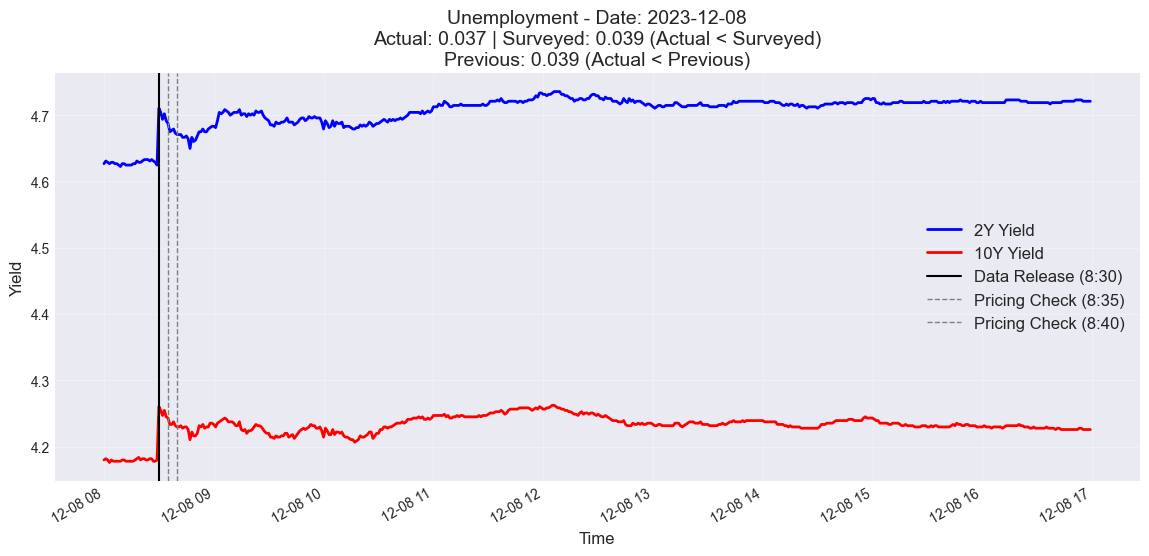

--------------------------------------------------


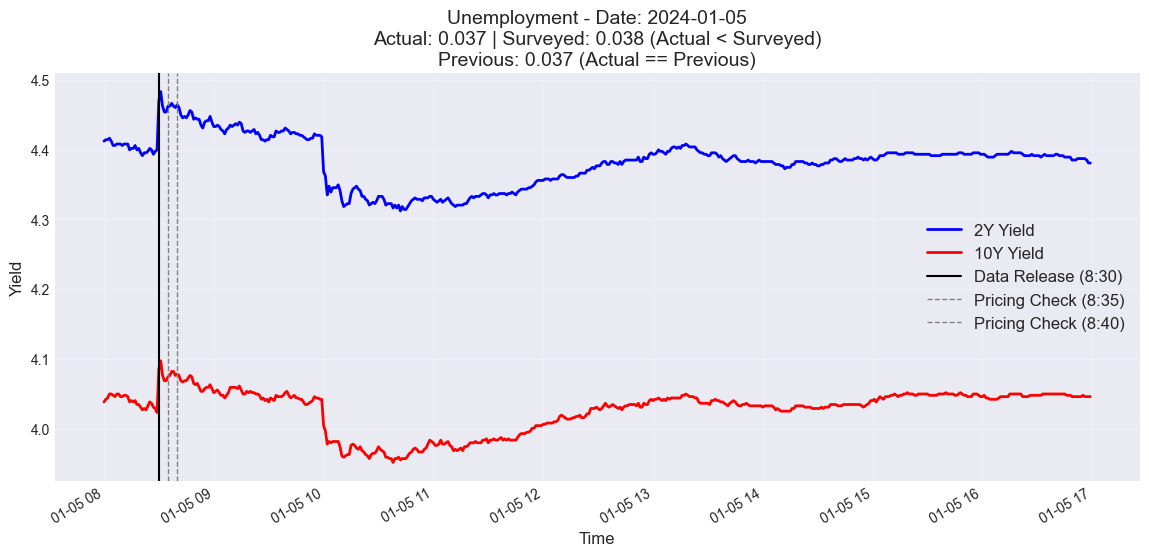

--------------------------------------------------


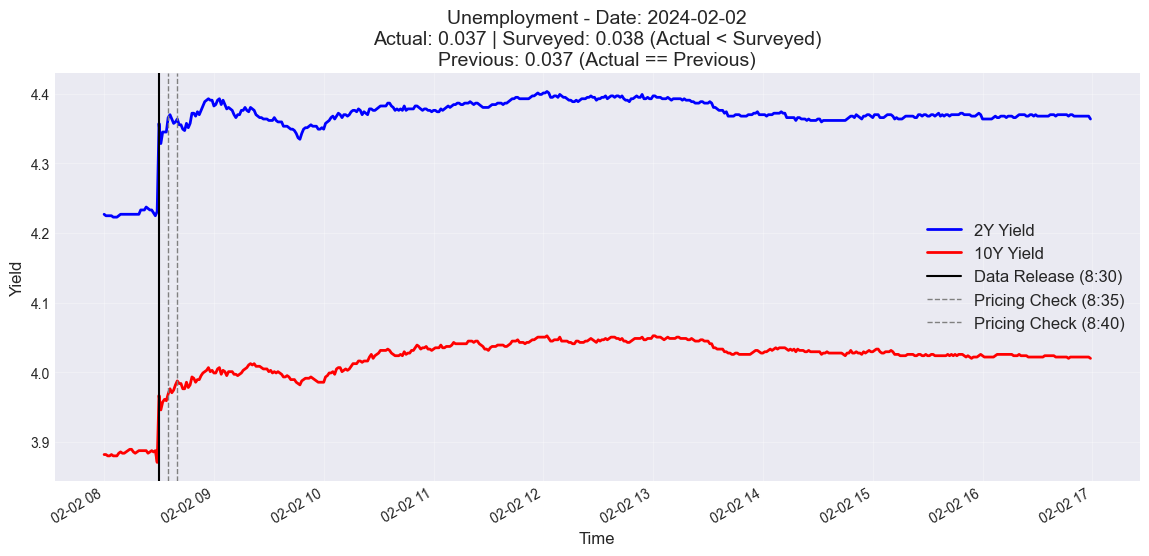

--------------------------------------------------


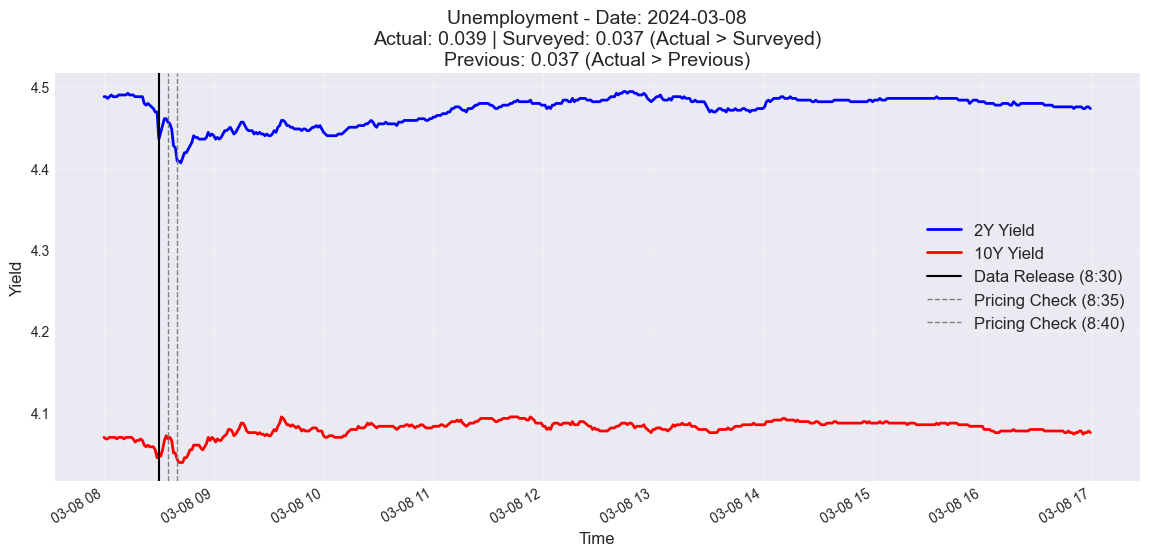

--------------------------------------------------


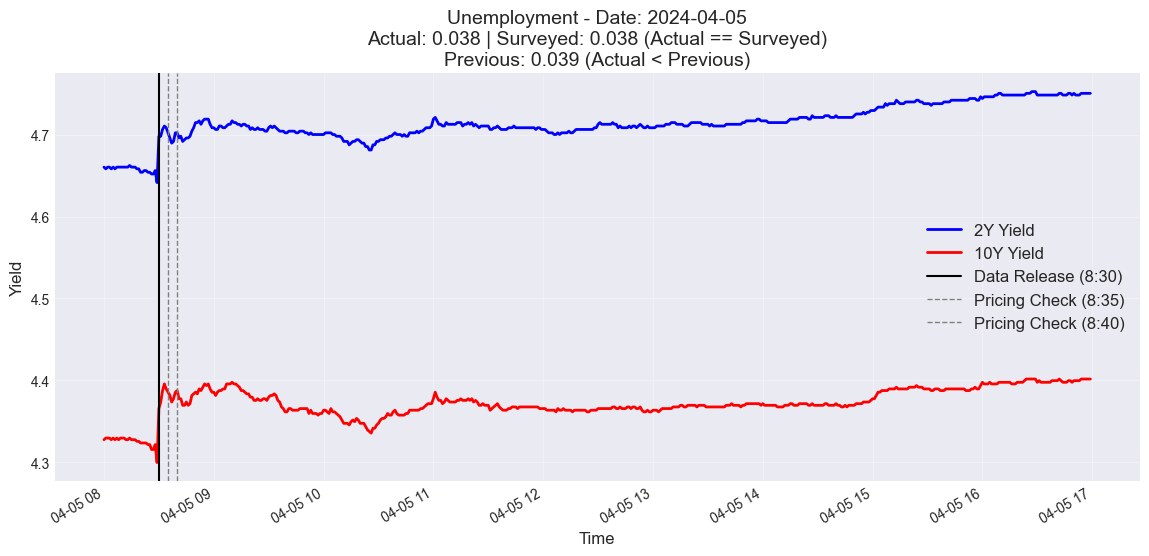

--------------------------------------------------


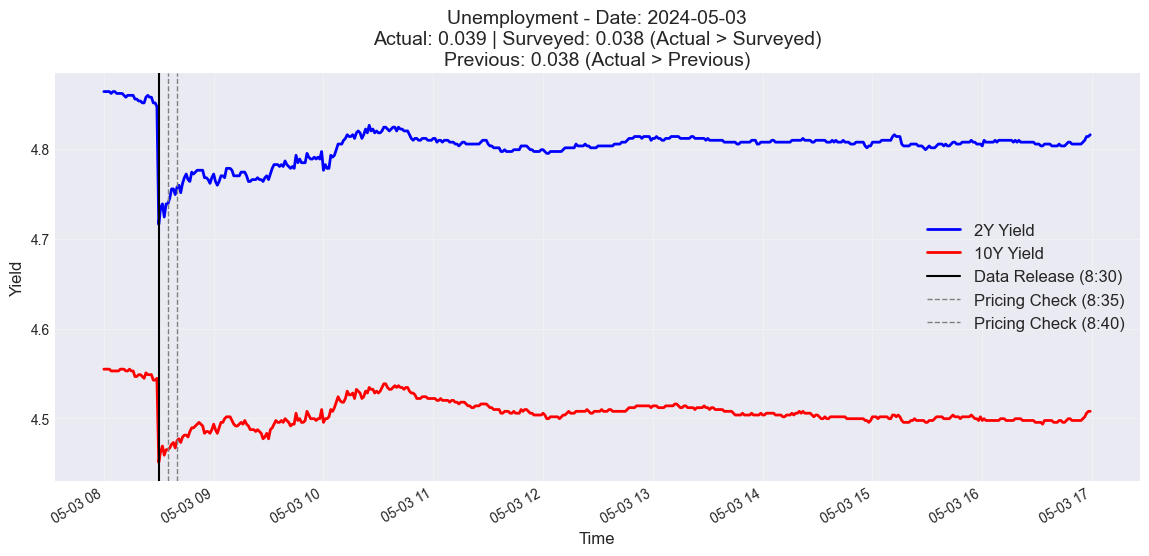

--------------------------------------------------


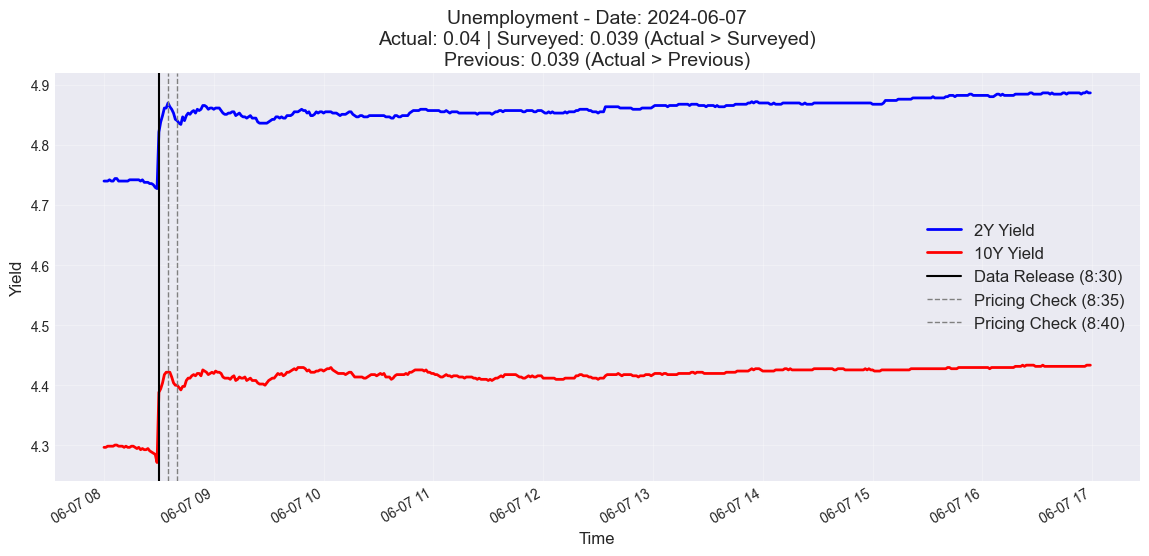

--------------------------------------------------


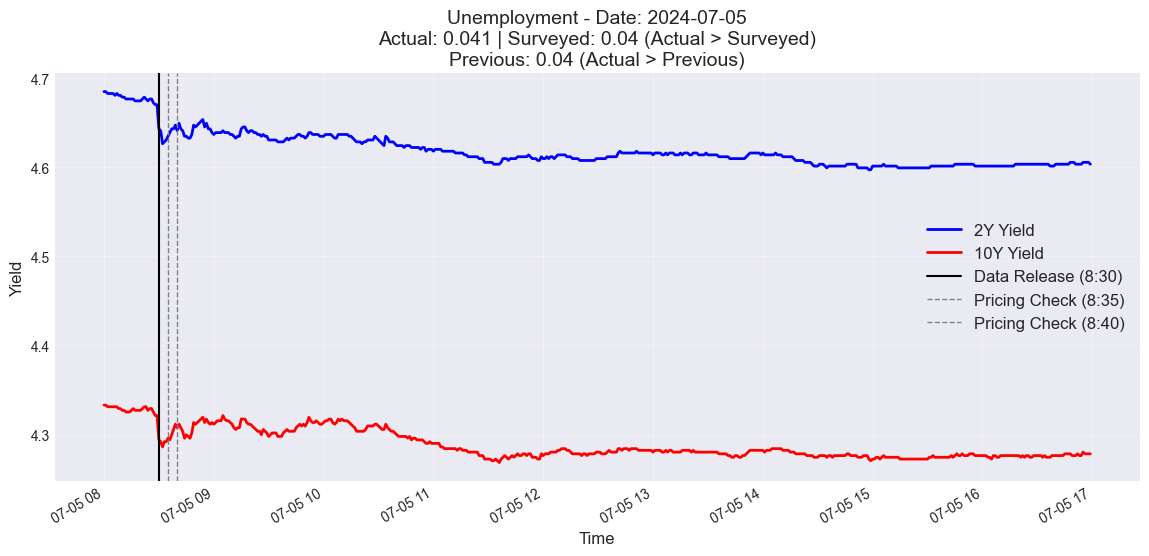

--------------------------------------------------


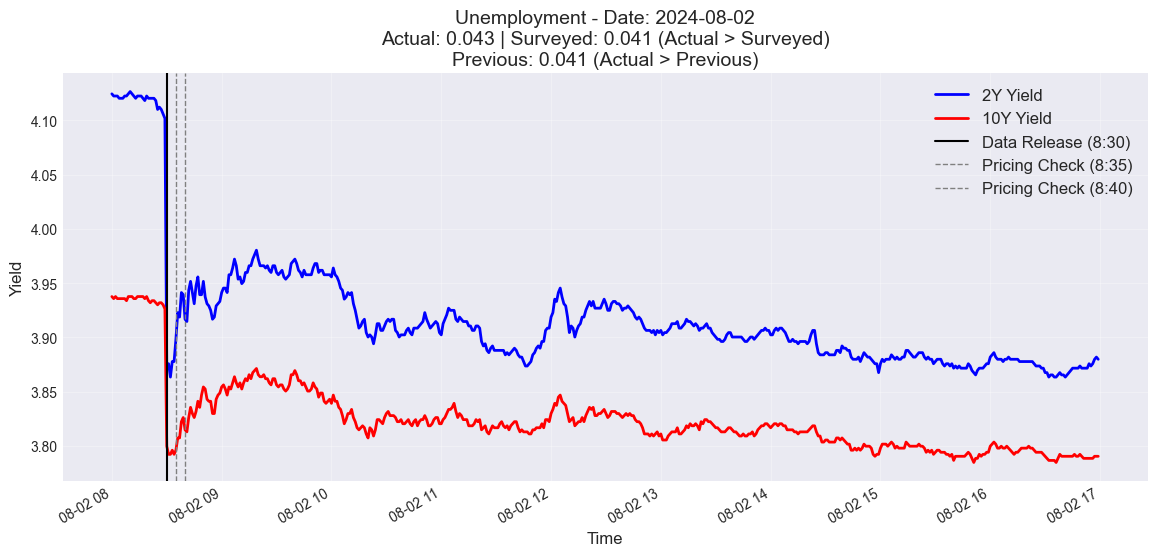

--------------------------------------------------


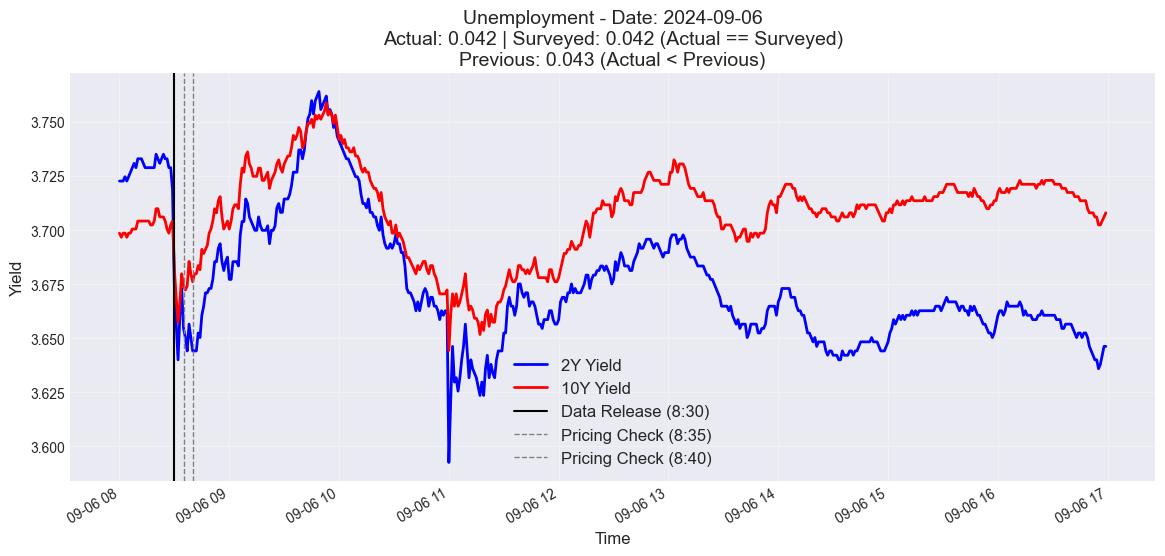

--------------------------------------------------


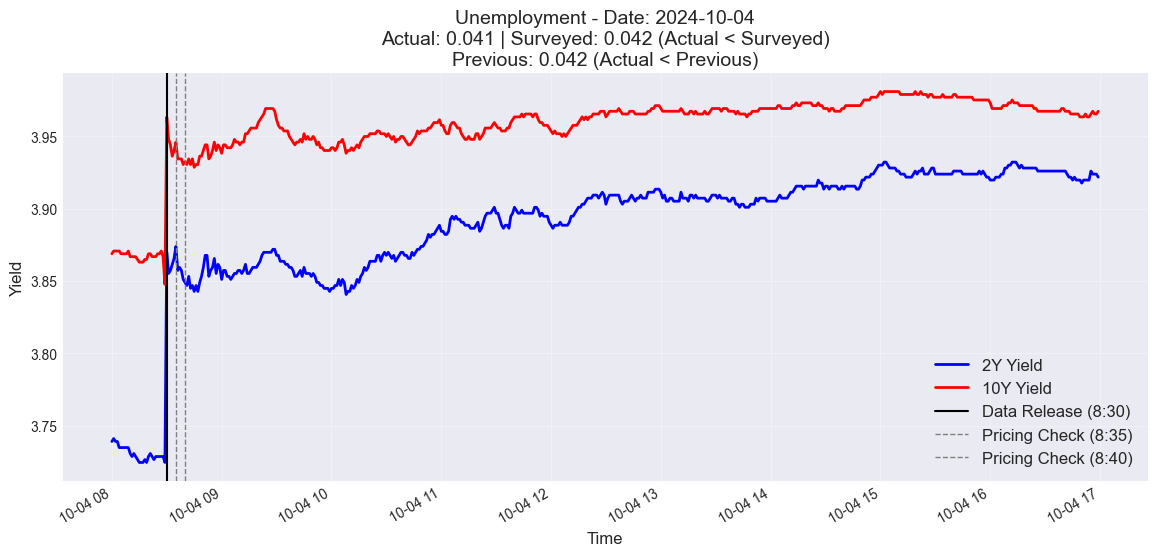

--------------------------------------------------


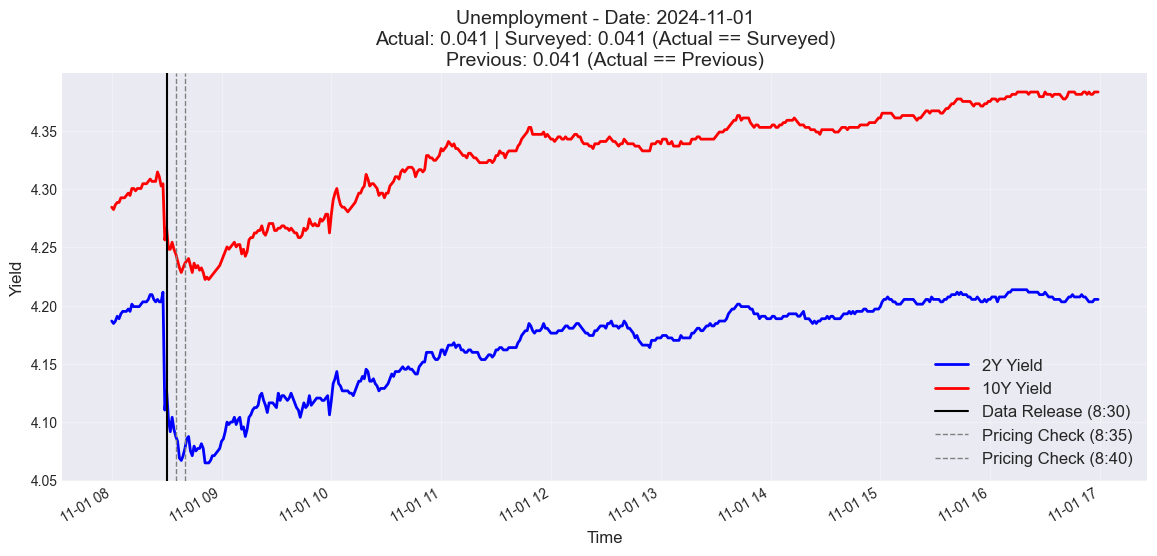

--------------------------------------------------


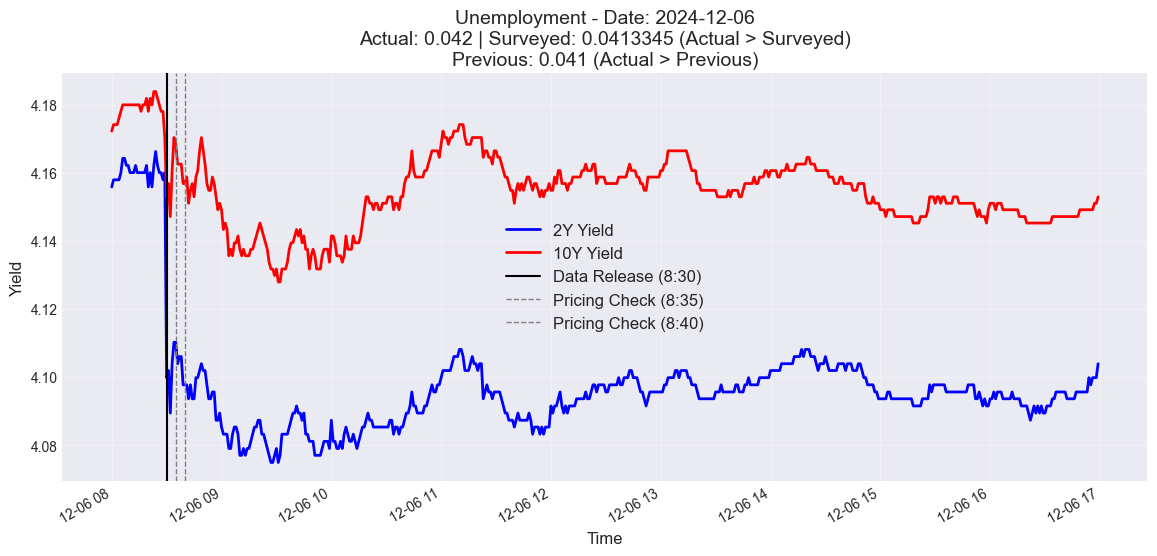

--------------------------------------------------


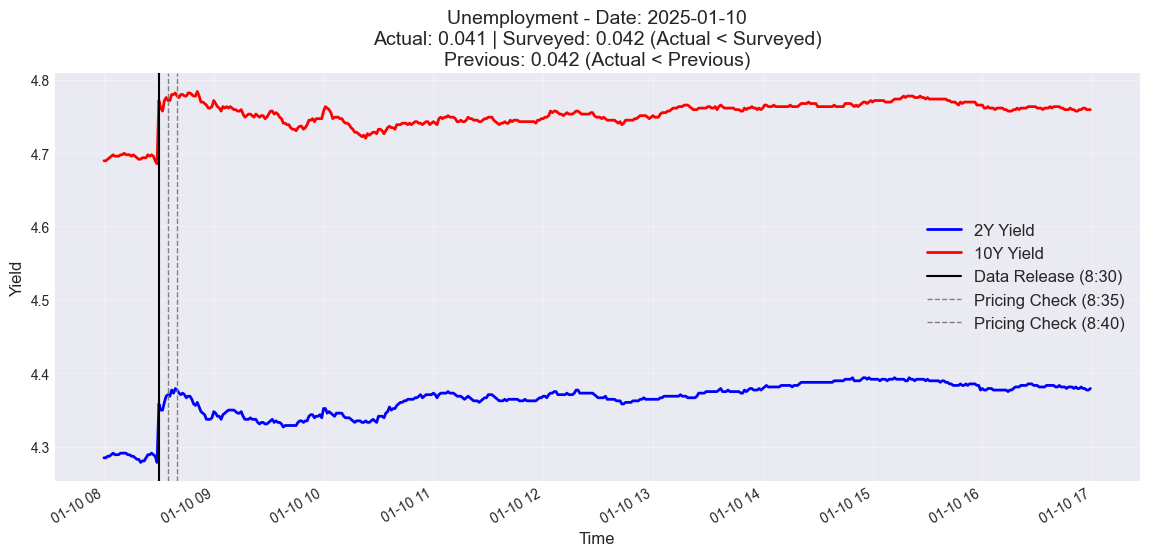

--------------------------------------------------


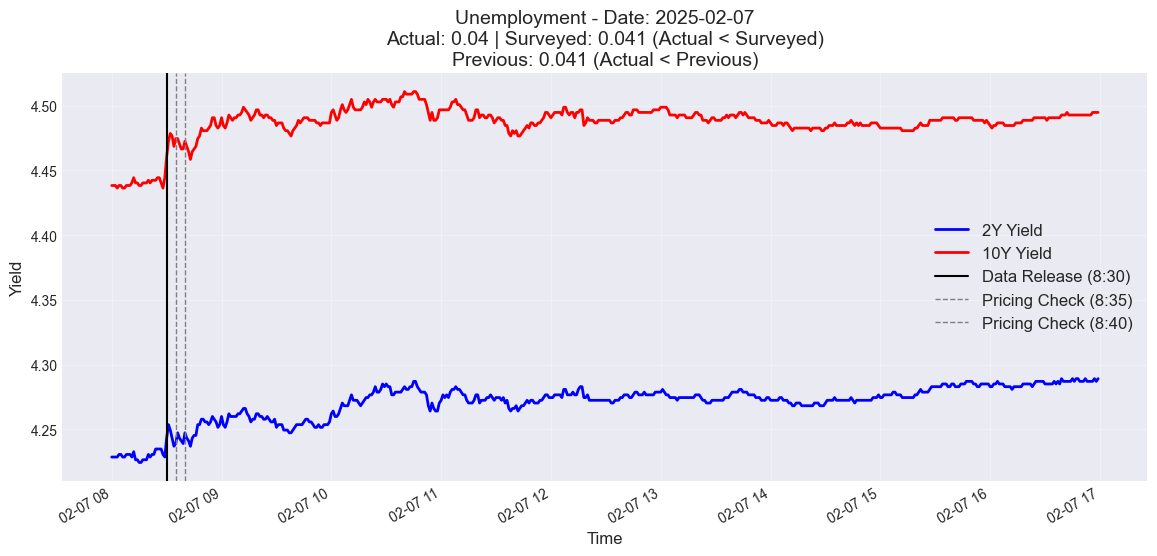

--------------------------------------------------


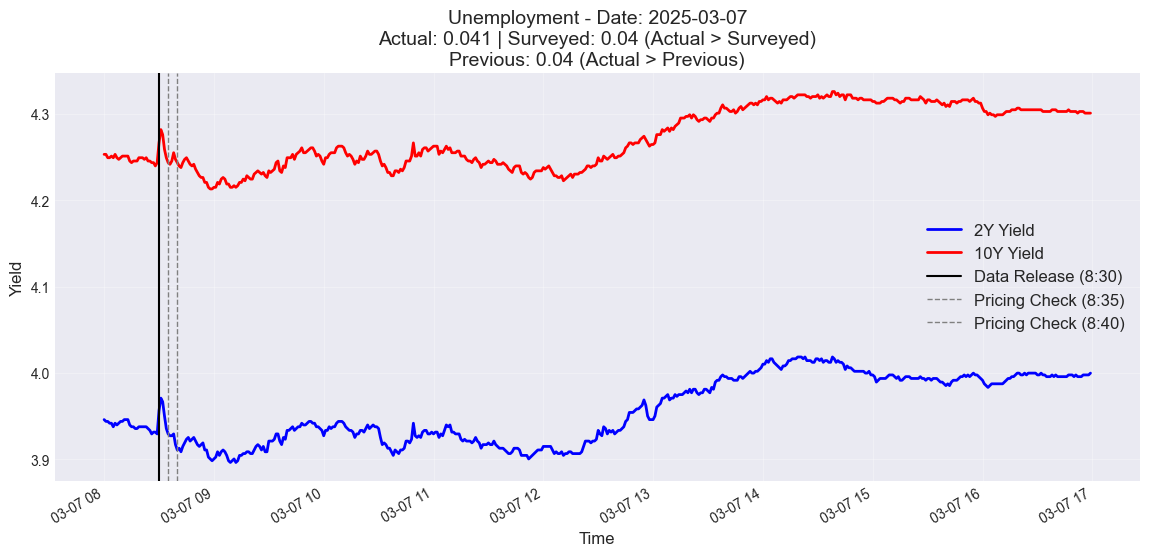

--------------------------------------------------


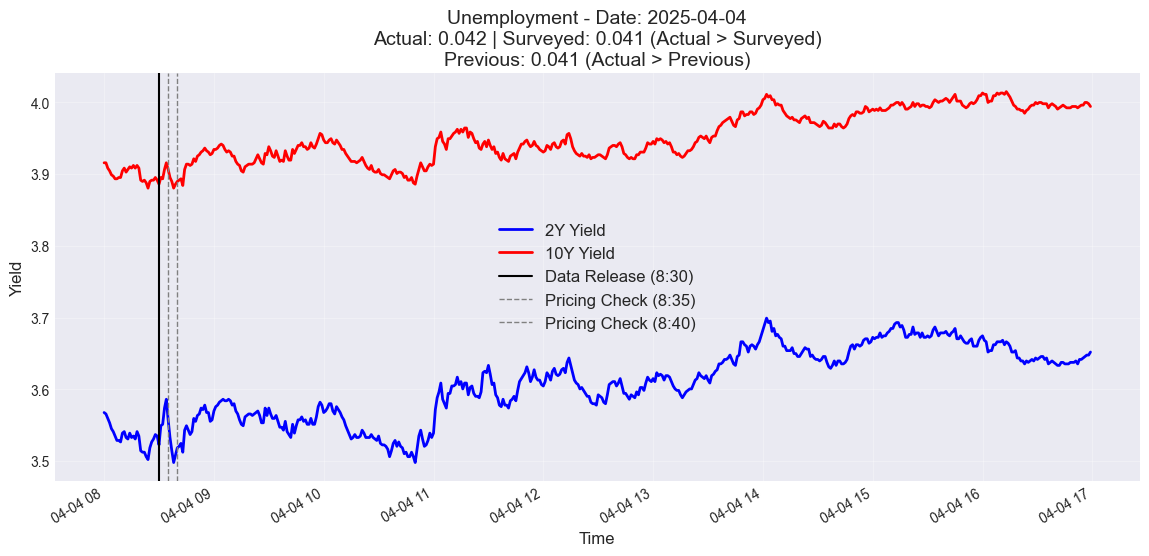

--------------------------------------------------


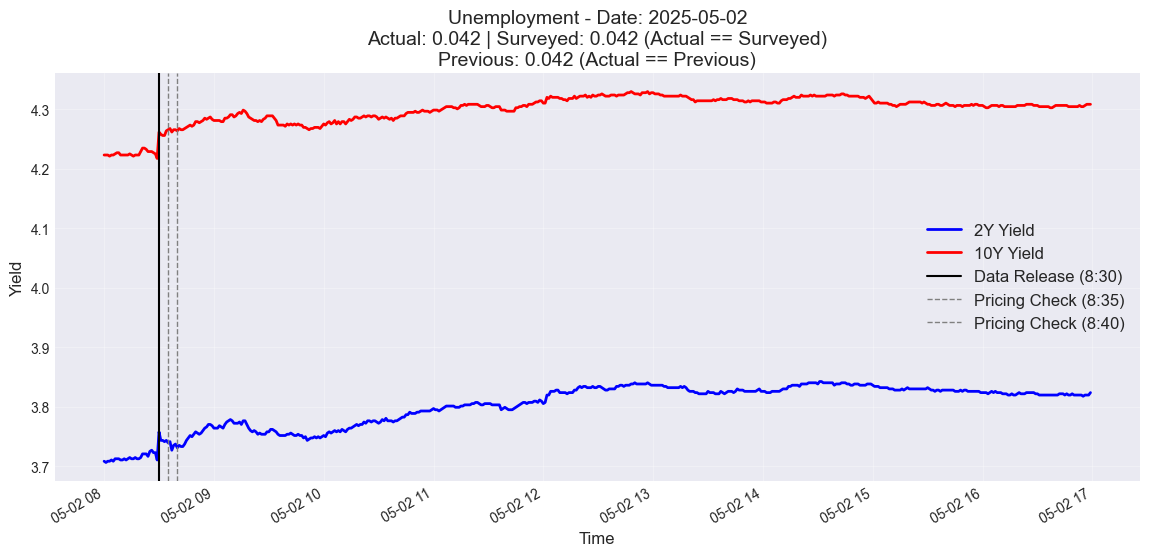

--------------------------------------------------


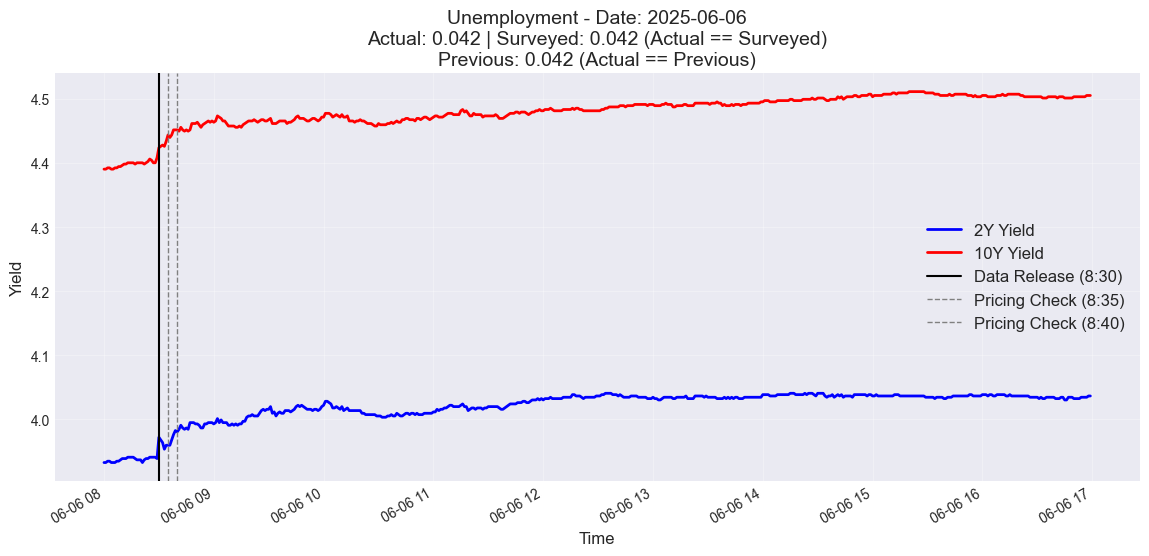

--------------------------------------------------


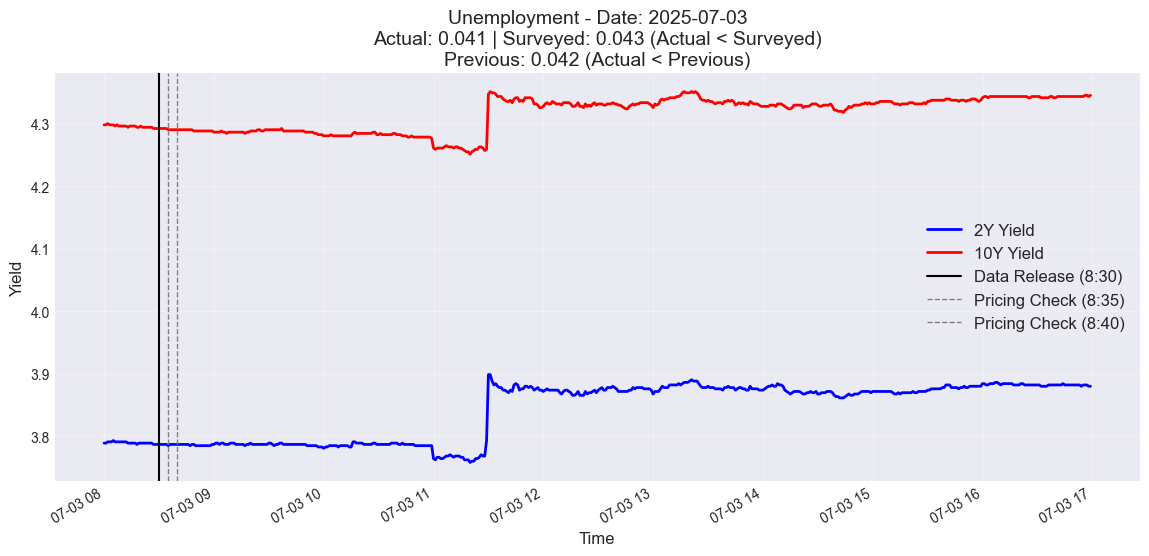

--------------------------------------------------


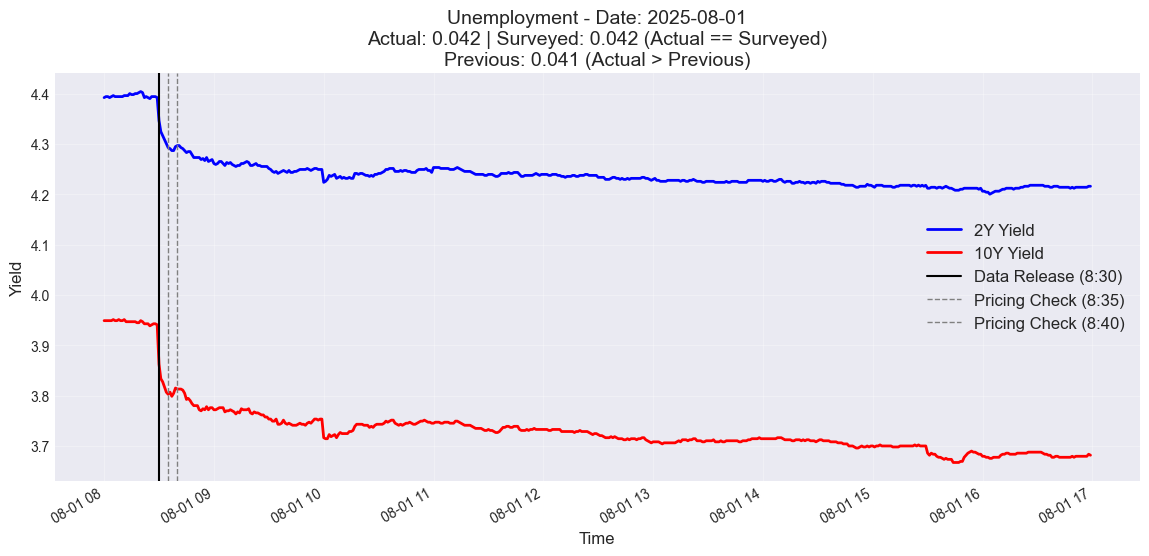

--------------------------------------------------


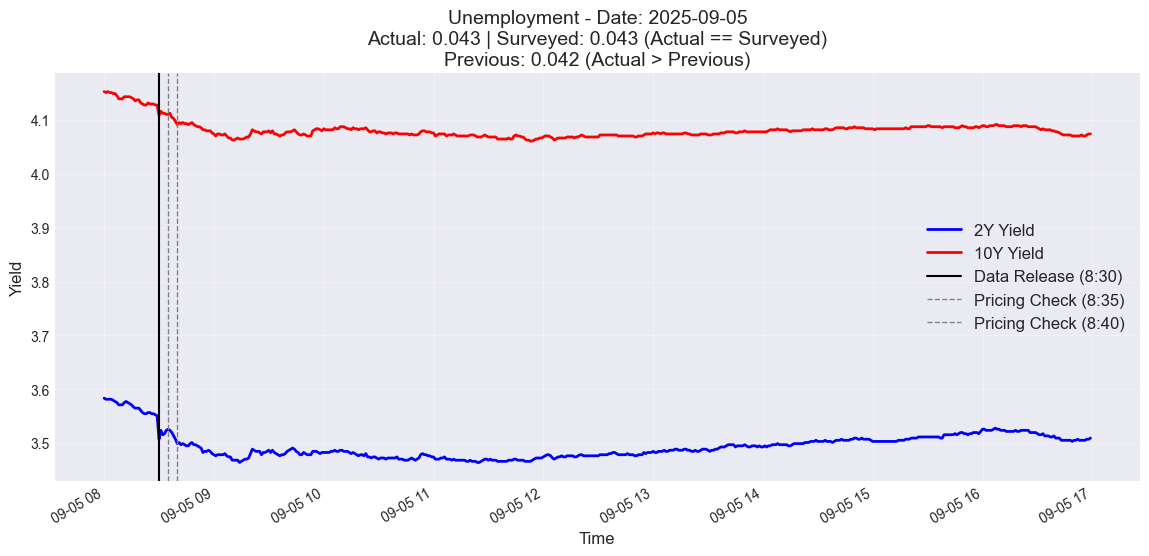

--------------------------------------------------


In [7]:
plot_event_data('cleaned_unemployment_data.csv', 'Unemployment')

## CPI Data Analysis

--- Analyzing CPI Data ---
Found 27 unique dates.


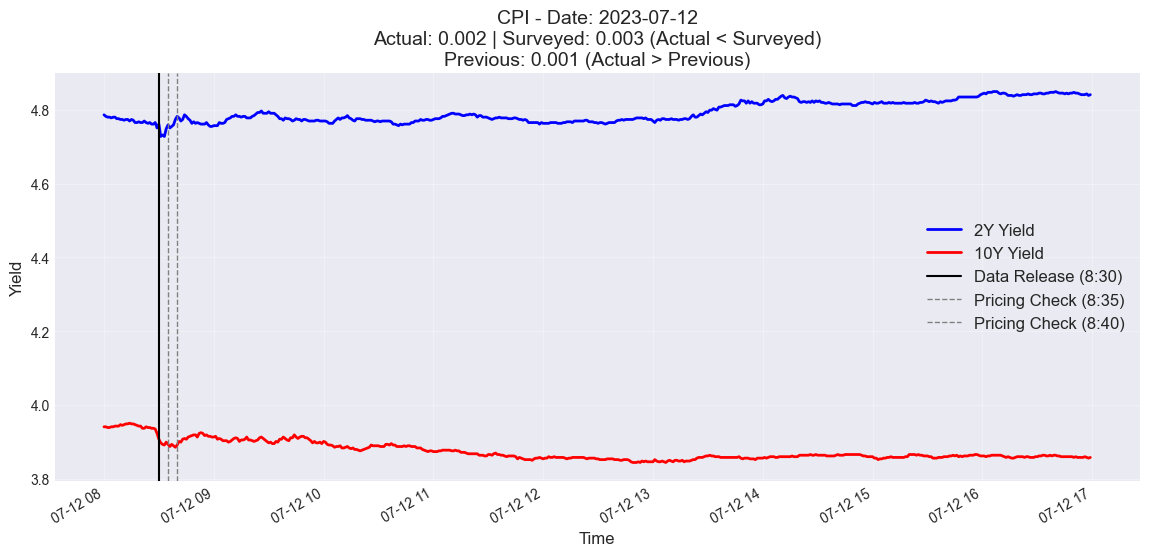

--------------------------------------------------


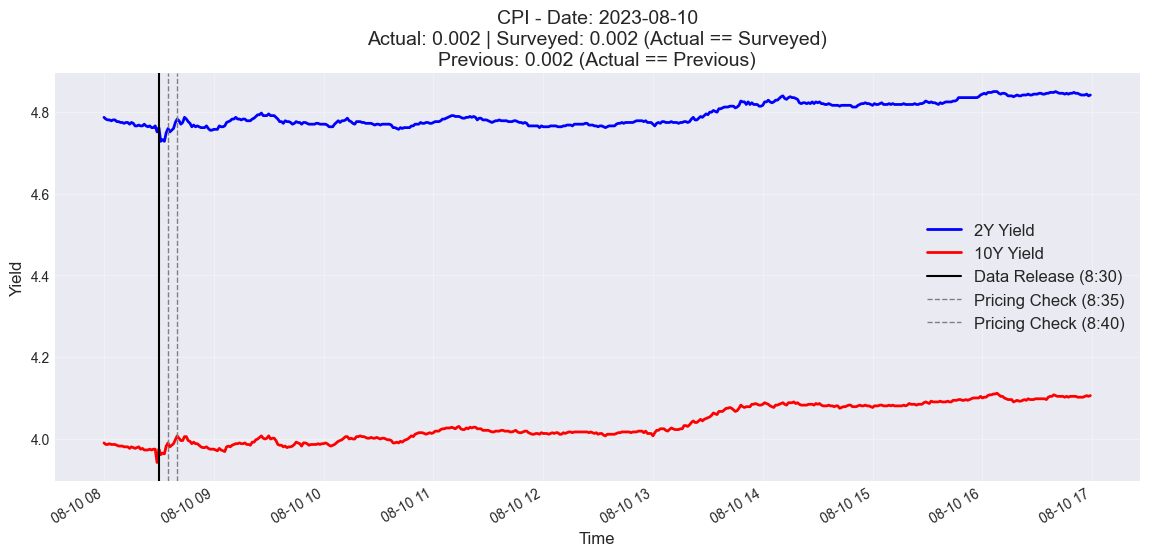

--------------------------------------------------


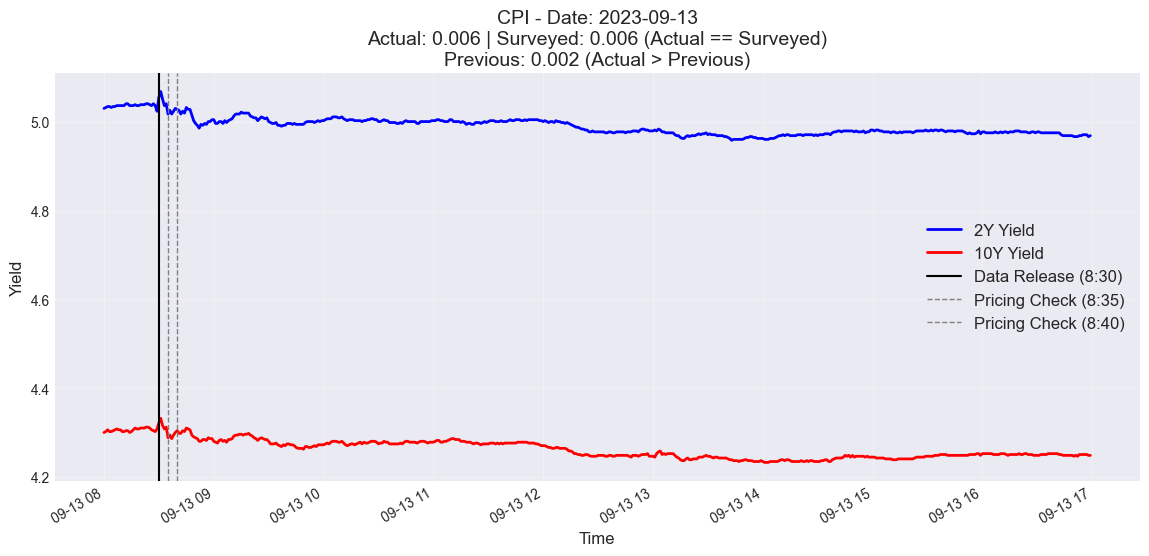

--------------------------------------------------


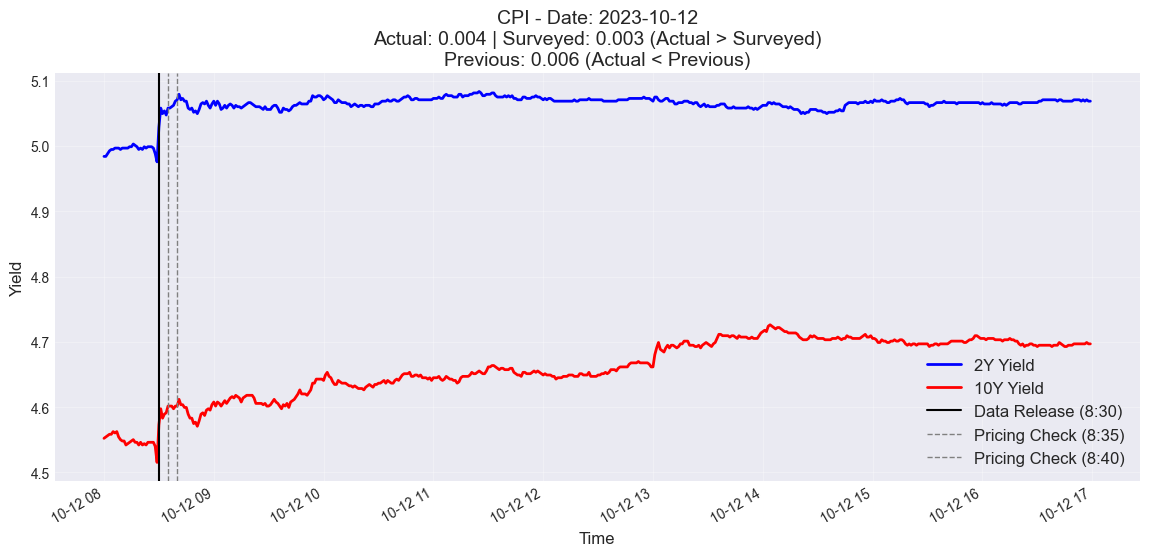

--------------------------------------------------


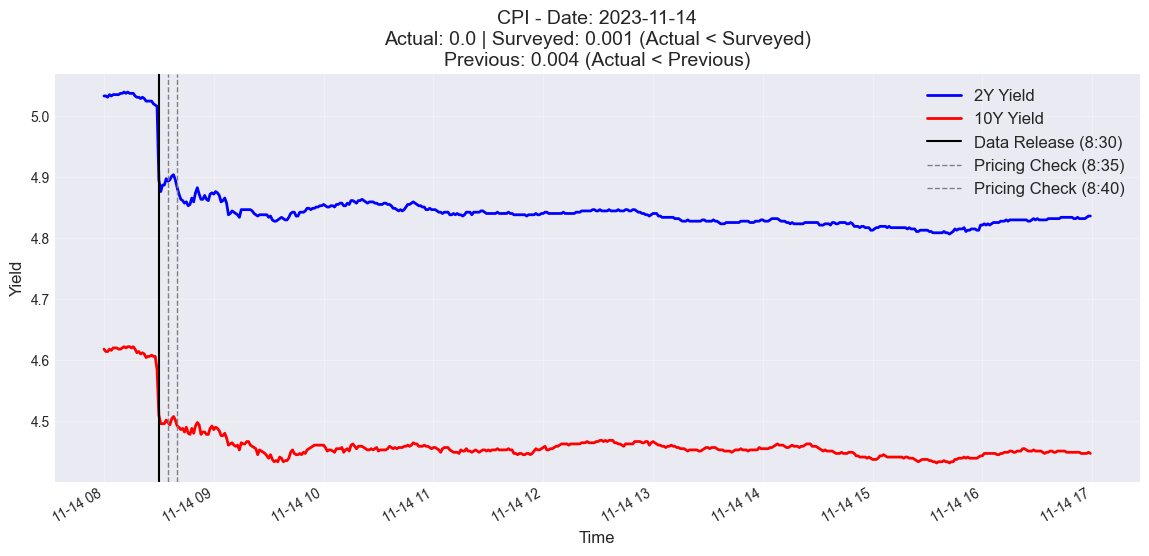

--------------------------------------------------


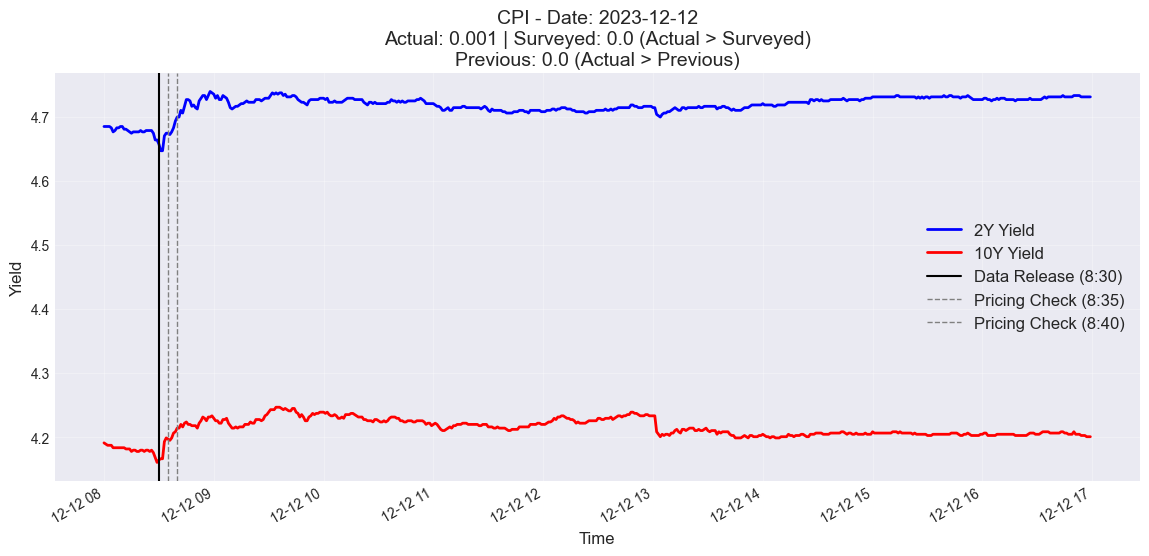

--------------------------------------------------


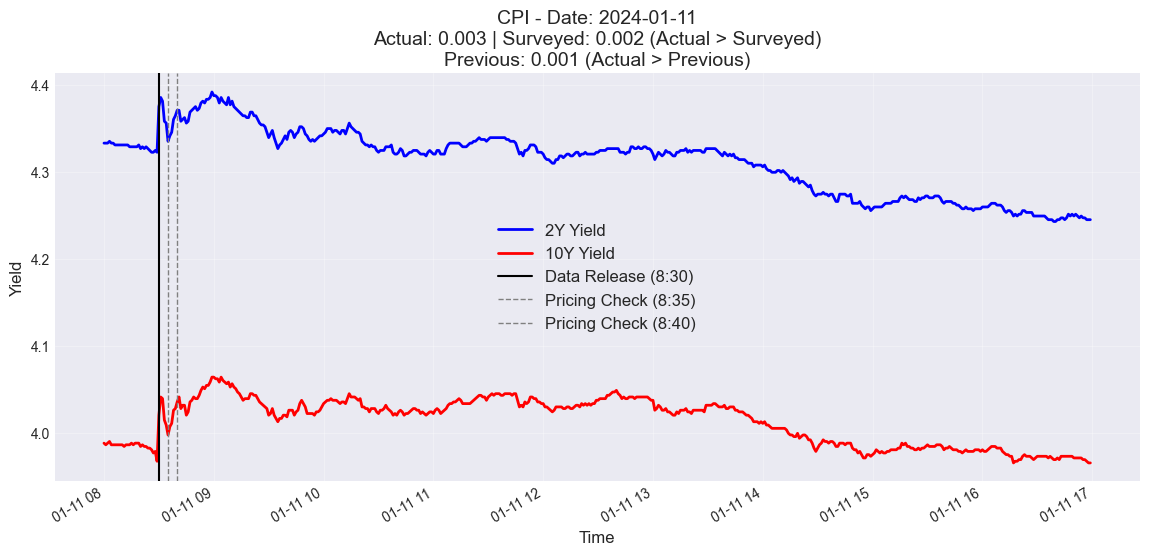

--------------------------------------------------


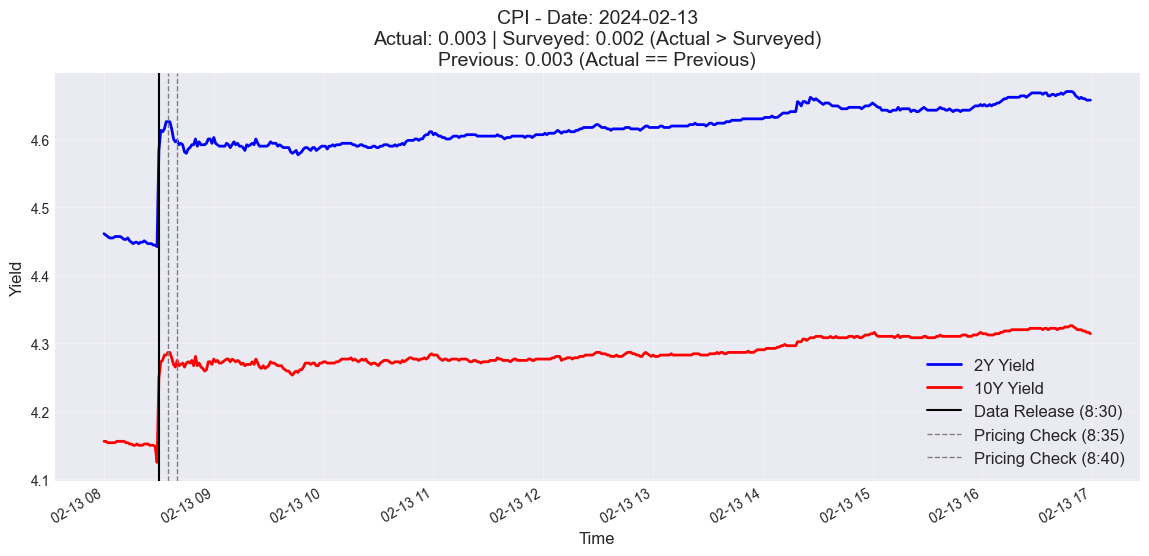

--------------------------------------------------


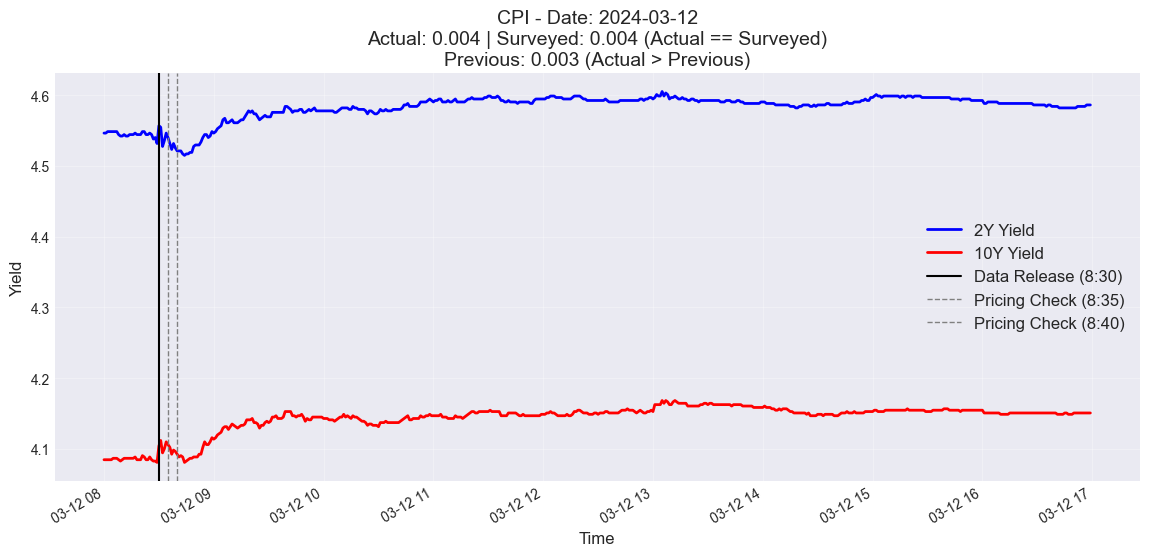

--------------------------------------------------


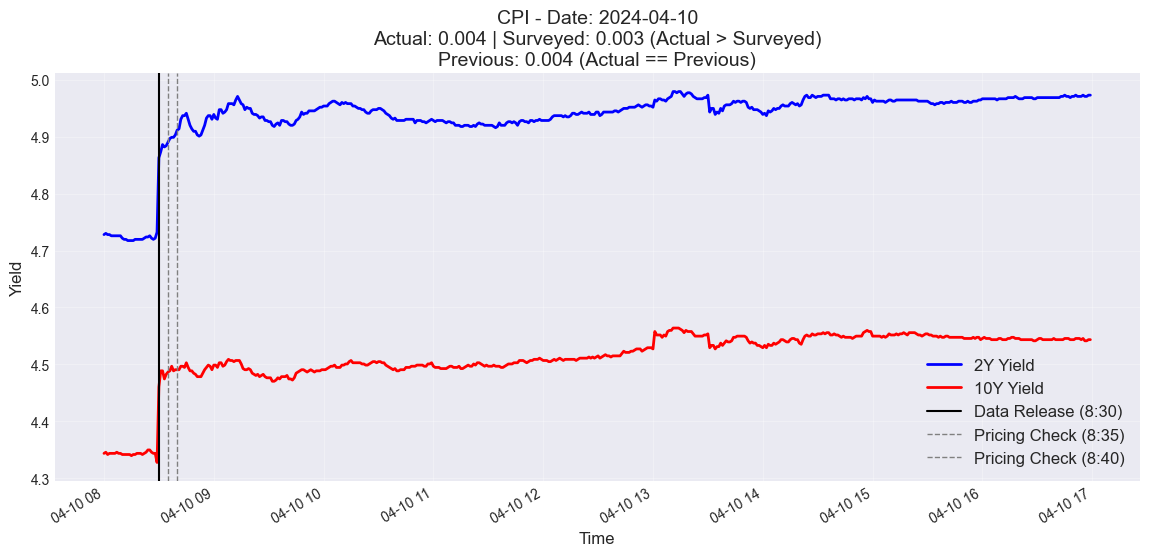

--------------------------------------------------


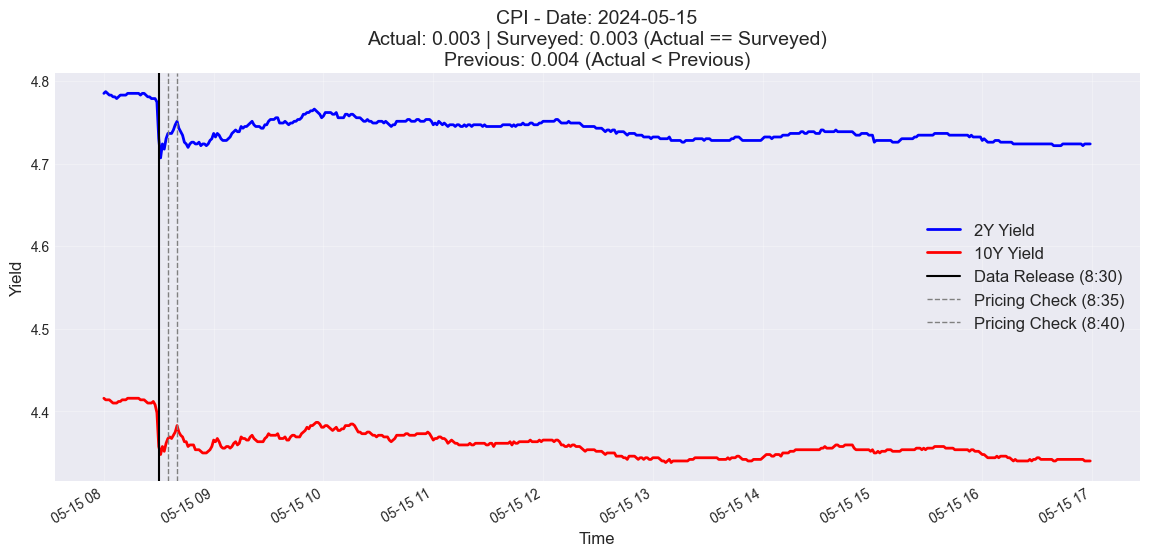

--------------------------------------------------


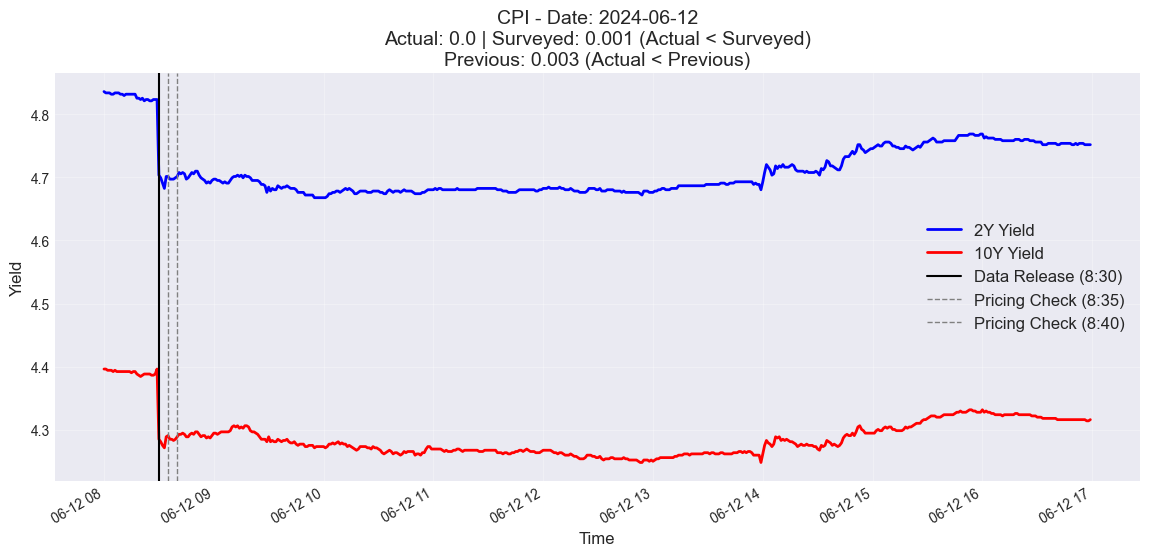

--------------------------------------------------


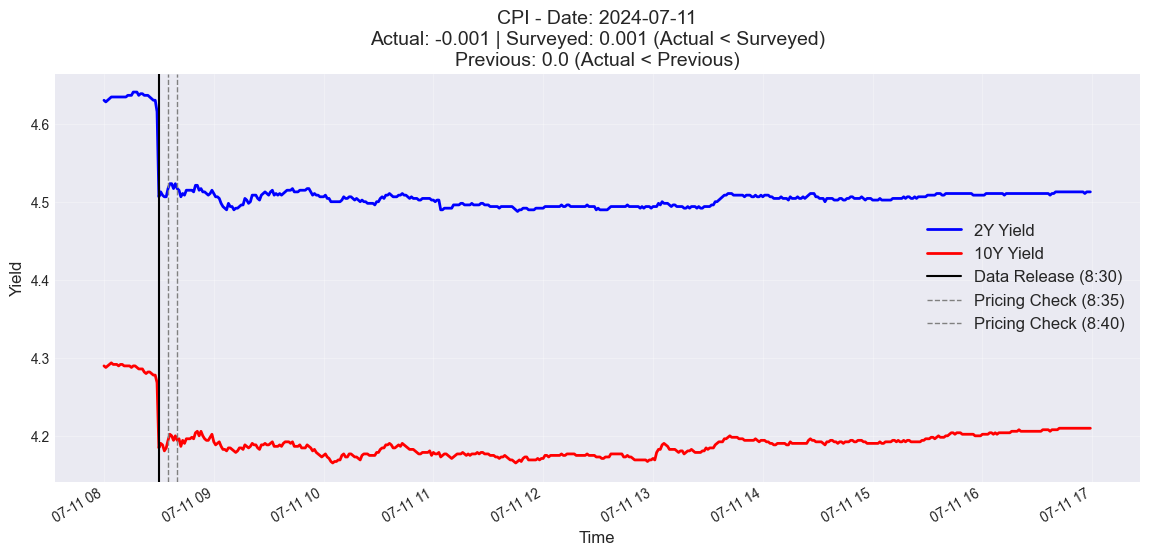

--------------------------------------------------


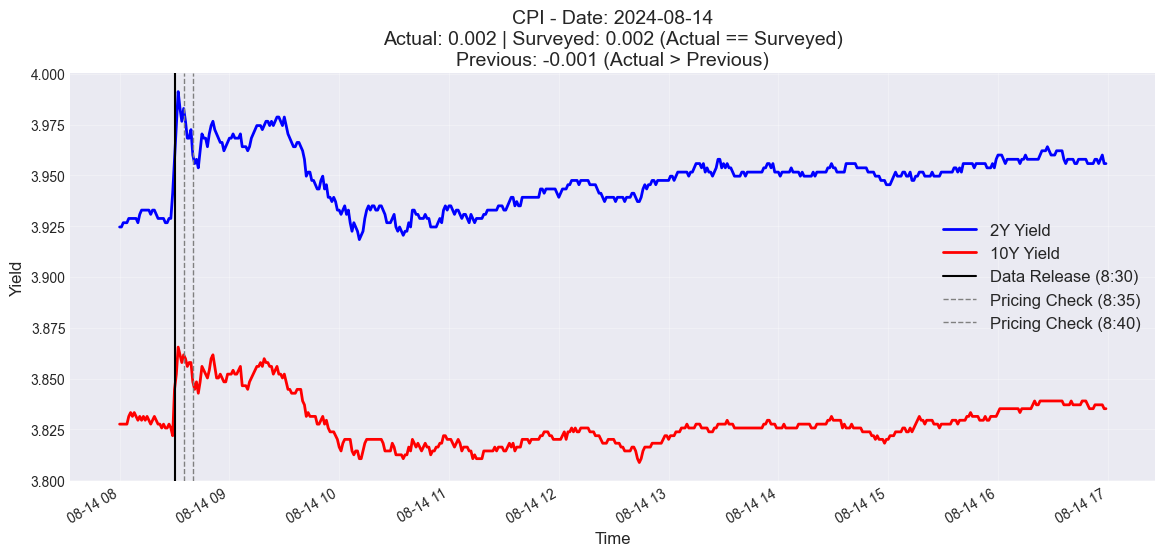

--------------------------------------------------


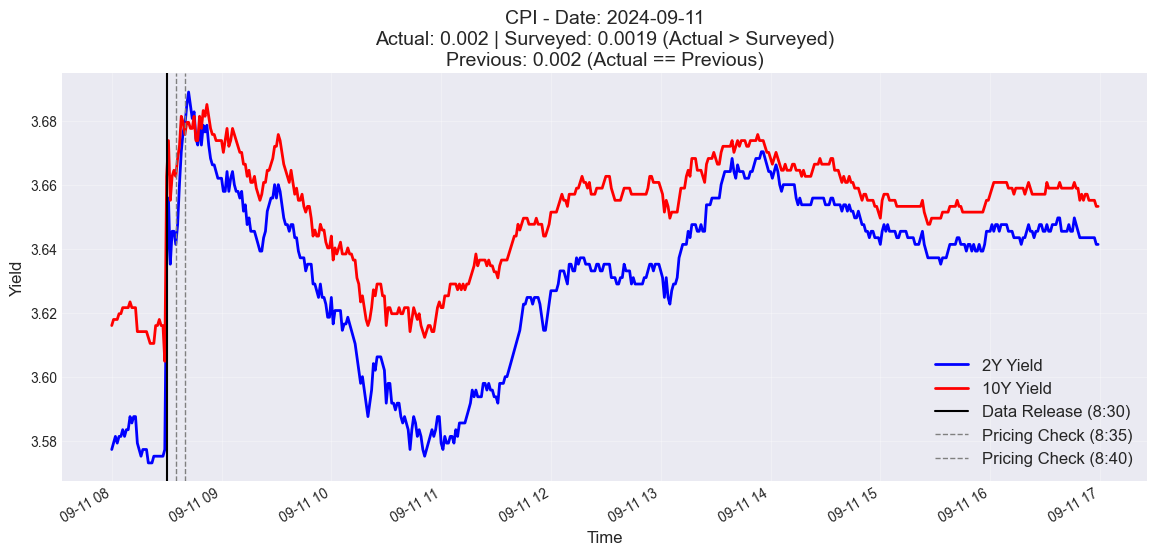

--------------------------------------------------


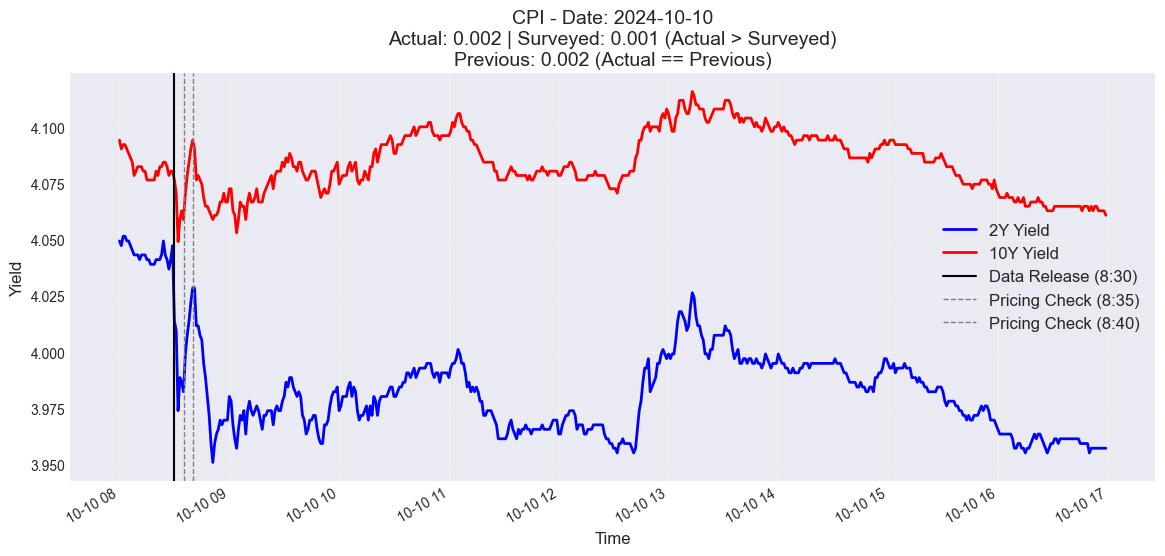

--------------------------------------------------


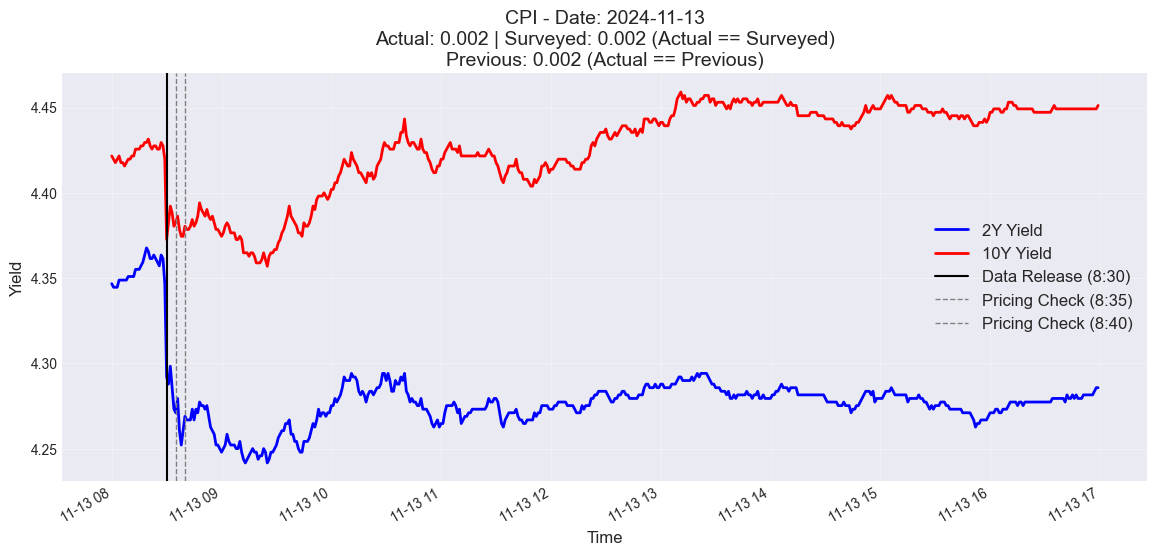

--------------------------------------------------


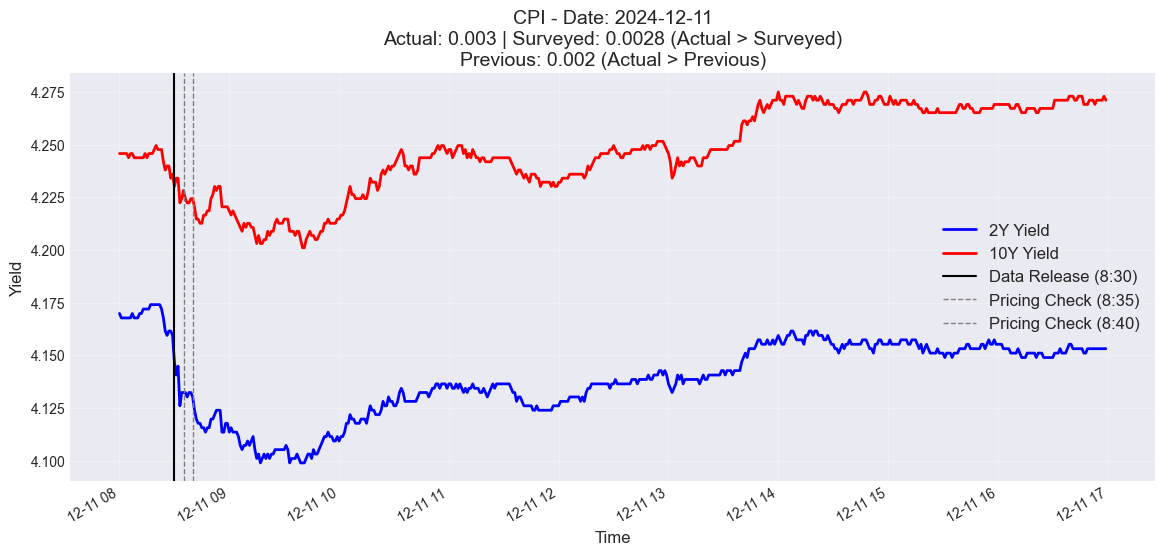

--------------------------------------------------


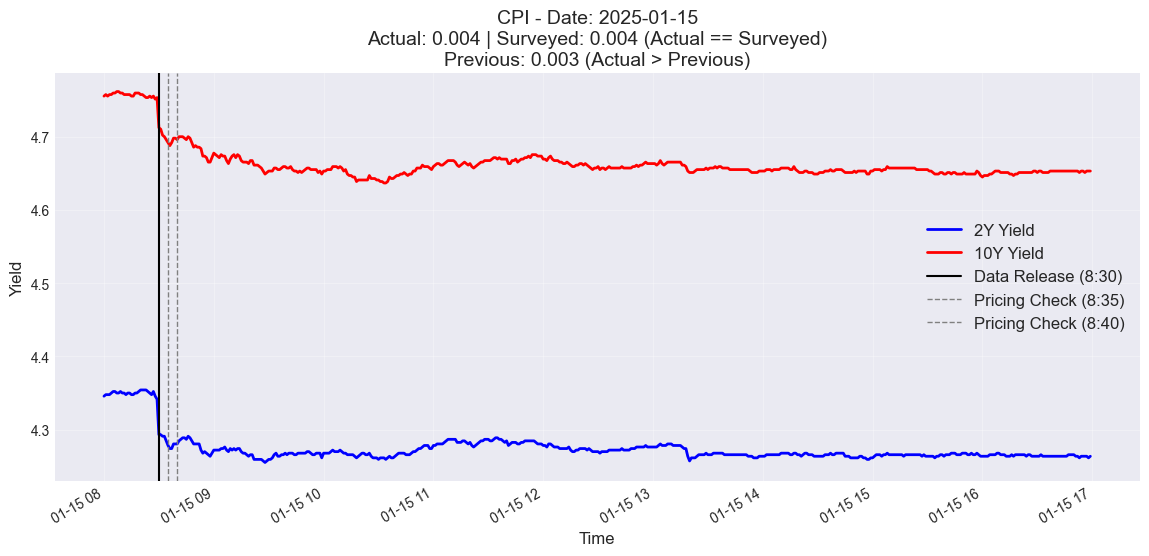

--------------------------------------------------


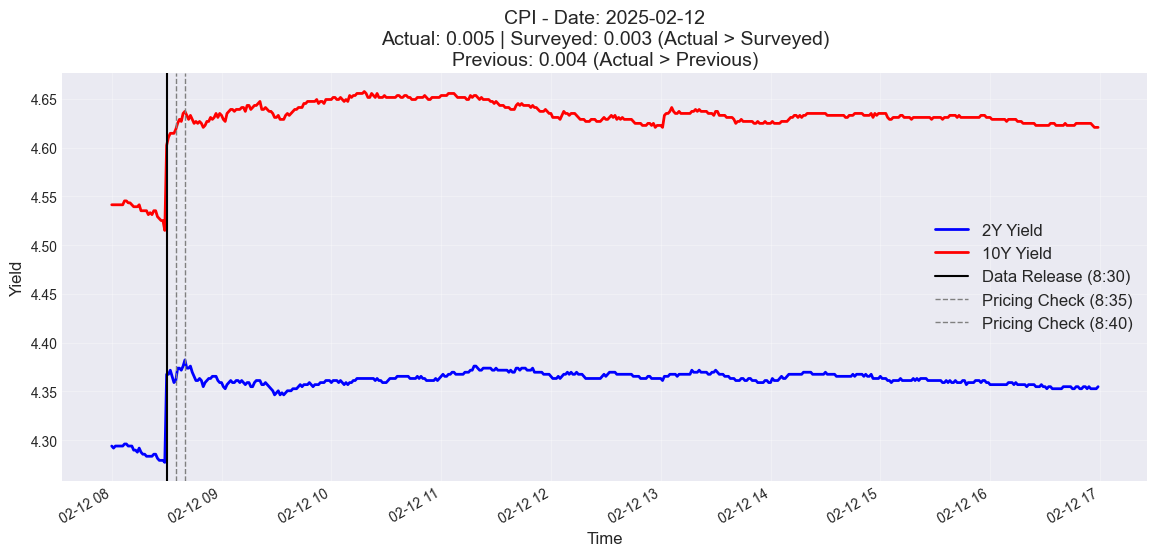

--------------------------------------------------


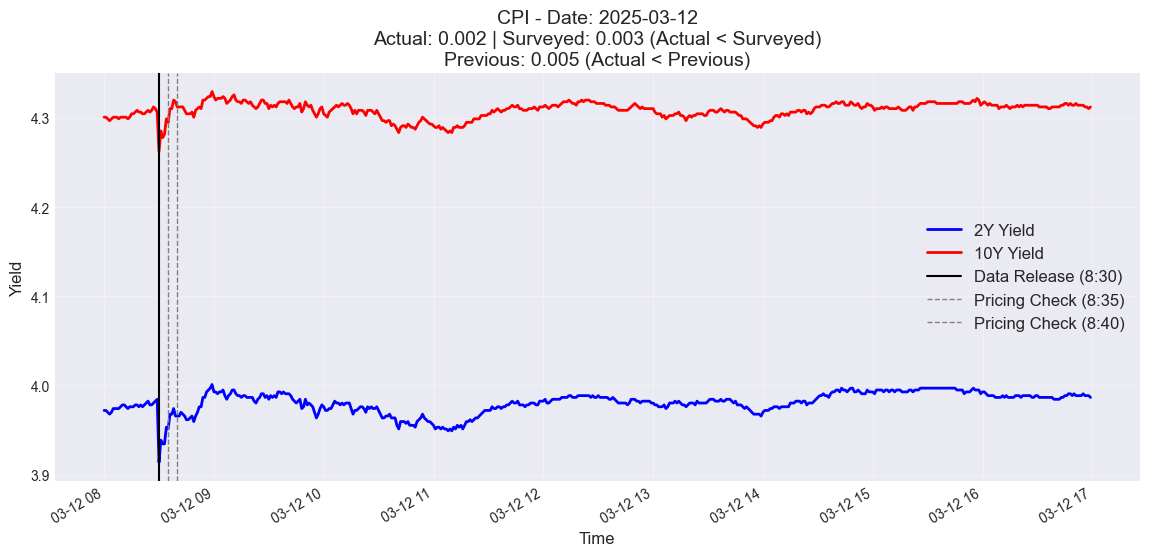

--------------------------------------------------


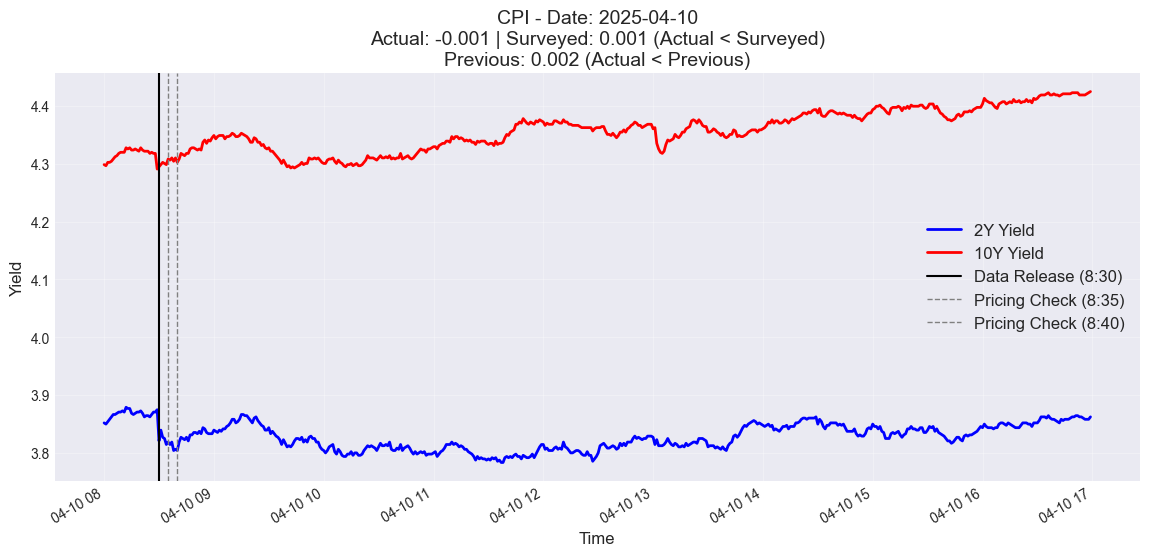

--------------------------------------------------


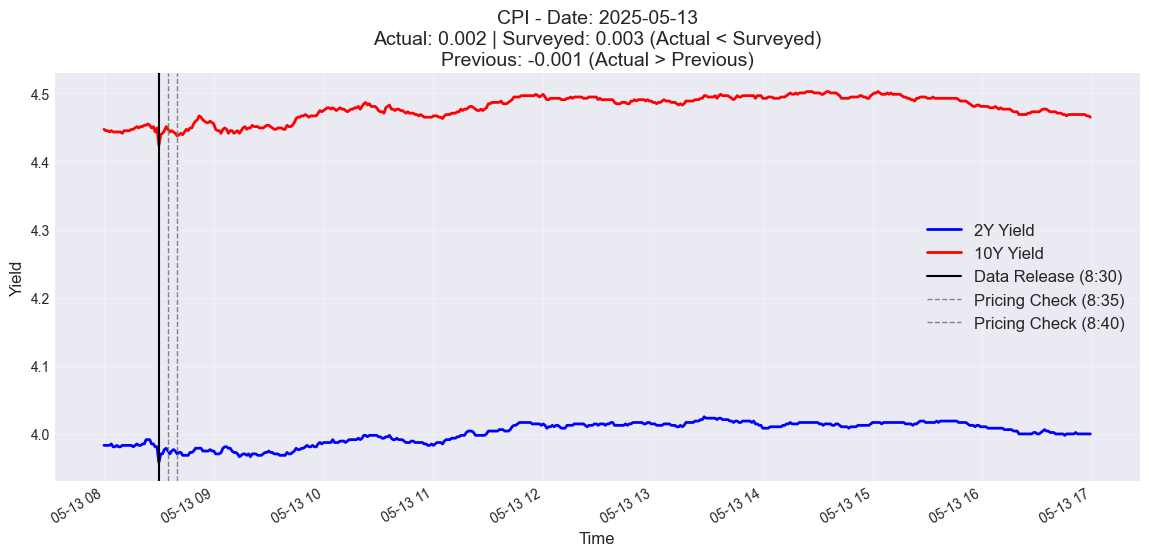

--------------------------------------------------


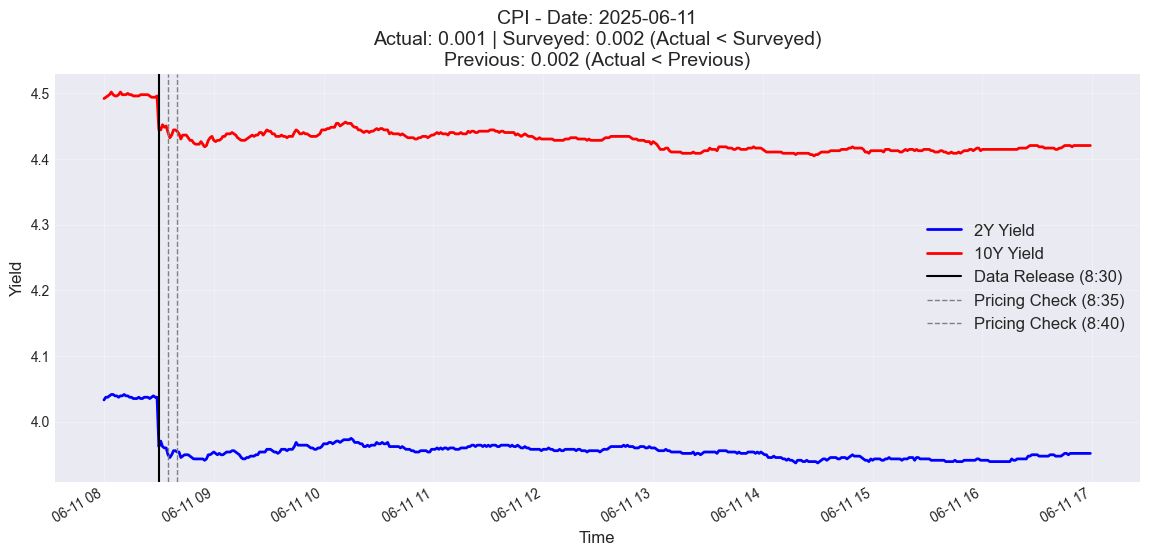

--------------------------------------------------


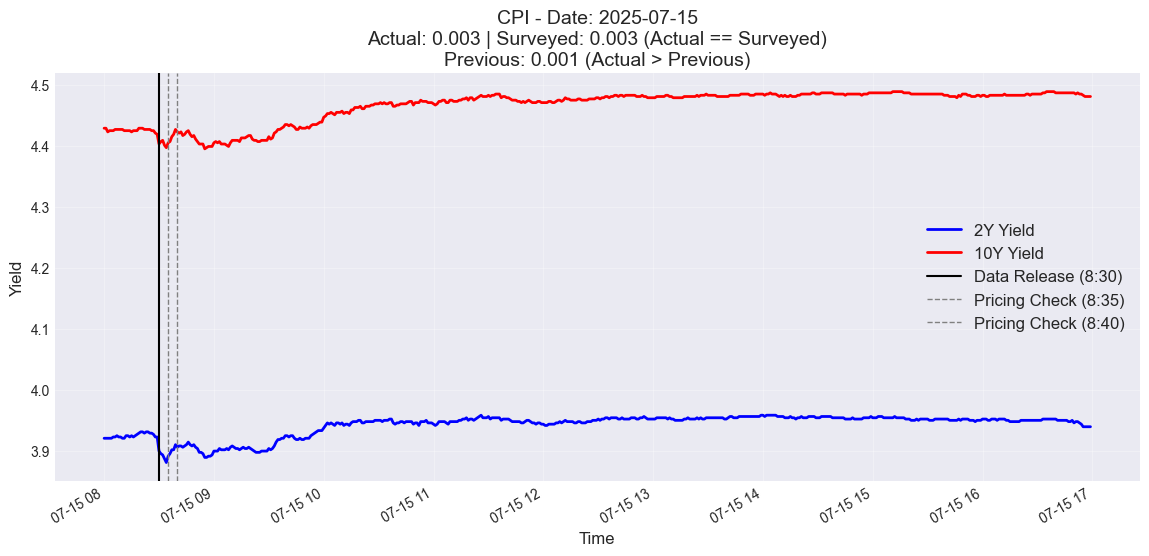

--------------------------------------------------


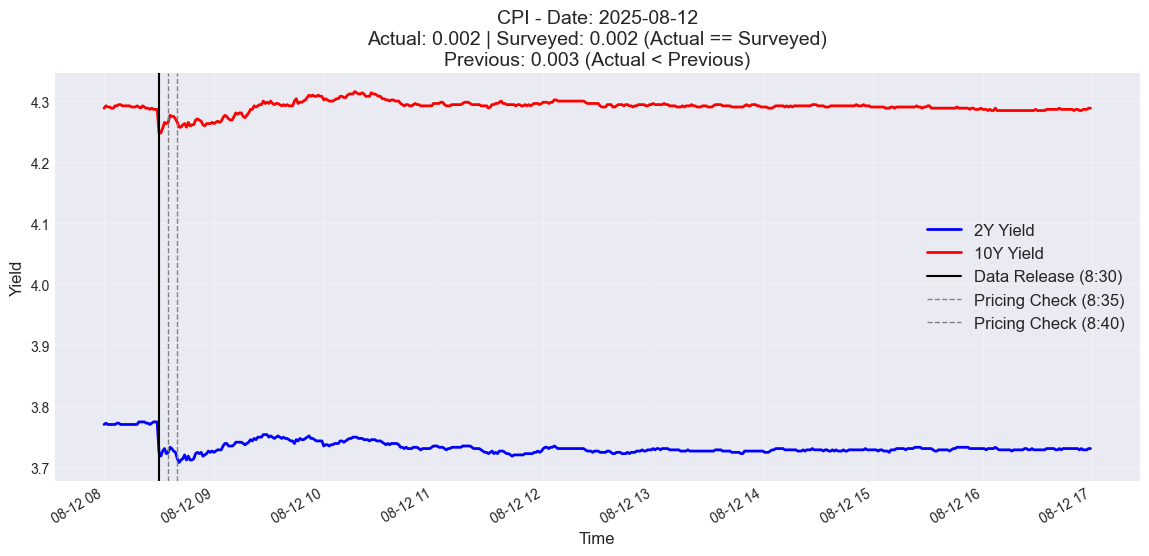

--------------------------------------------------


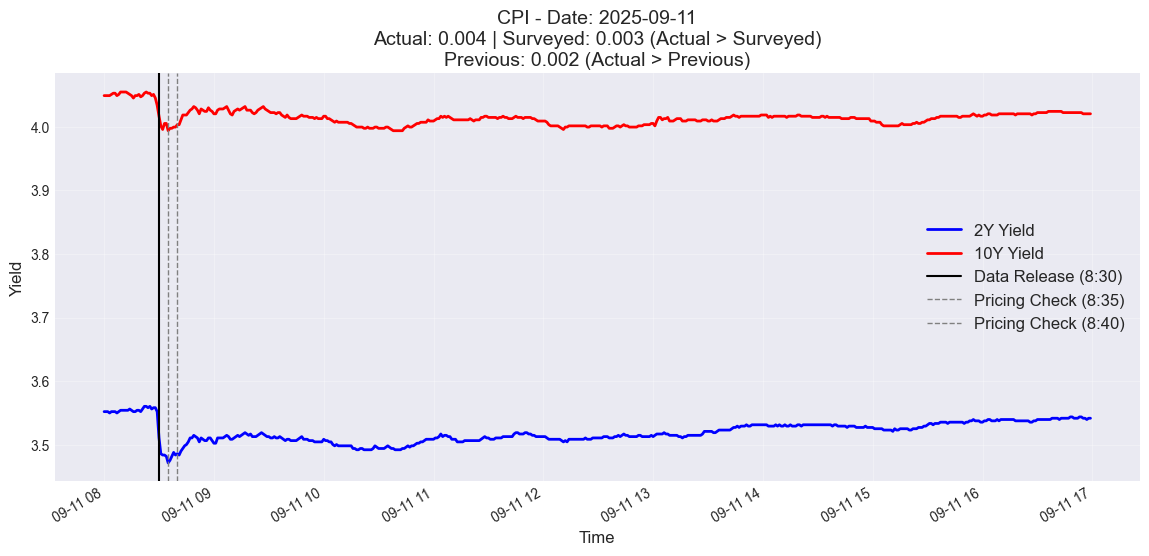

--------------------------------------------------


In [8]:
plot_event_data('cleaned_cpi_data.csv', 'CPI')

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import os

def plot_event_data_until_noon(file_path, event_name):
    """
    Loads data from a CSV, groups by Date, and plots yield behavior 
    ONLY from the beginning of the day until 12:00 PM.
    """
    if not os.path.exists(file_path):
        print(f"File not found: {file_path}")
        return

    df = pd.read_csv(file_path)
    
    # Ensure Datetime is a datetime object
    df['Datetime'] = pd.to_datetime(df['Datetime'])
    
    # Group by Date
    grouped = df.groupby('Date')
    
    print(f"--- Analyzing {event_name} Data (Up to 12:00 PM) ---")
    print(f"Found {len(grouped)} unique dates.")
    
    for date, group in grouped:
        # ---------------------------------------------------------
        # NEW CODE: Filter Data to End at 12:00 PM
        # ---------------------------------------------------------
        # Create a timestamp for 12:00 PM on the current date
        t_noon = pd.Timestamp(f"{date} 12:00:00")
        
        # Filter the group to only include times <= 12:00 PM
        group = group[group['Datetime'] <= t_noon]
        
        # If no data remains after filtering, skip this date
        if group.empty:
            print(f"No data found before 12:00 PM for {date}. Skipping.")
            continue
        # ---------------------------------------------------------

        # Sort by time
        group = group.sort_values('Datetime')
        
        # Get scalar values (using iloc[0] is safe as we sorted and checked empty)
        # Note: Depending on your data structure, scalar values like 'Actual' 
        # might be the same for all rows in the group.
        actual = group['Actual'].iloc[0]
        surveyed = group['Surveyed'].iloc[0]
        previous = group['Previous'].iloc[0]
        
        # Determine relationships
        if actual > surveyed:
            survey_rel = "Actual > Surveyed"
        elif actual < surveyed:
            survey_rel = "Actual < Surveyed"
        else:
            survey_rel = "Actual == Surveyed"
            
        if actual > previous:
            prev_rel = "Actual > Previous"
        elif actual < previous:
            prev_rel = "Actual < Previous"
        else:
            prev_rel = "Actual == Previous"
            
        title_text = (f"{event_name} - Date: {date}\n"
                      f"Actual: {actual} | Surveyed: {surveyed} ({survey_rel})\n"
                      f"Previous: {previous} ({prev_rel})")
        
        # Plotting
        plt.figure(figsize=(14, 6))
        
        # Plot 2Y Yield
        plt.plot(group['Datetime'], group['2Y_Yield'], label='2Y Yield', color='blue', linewidth=2)
        
        # Plot 10Y Yield (or 5Y if available)
        if '10Y_Yield' in group.columns:
            plt.plot(group['Datetime'], group['10Y_Yield'], label='10Y Yield', color='red', linewidth=2)
        elif '5Y_Yield' in group.columns:
            plt.plot(group['Datetime'], group['5Y_Yield'], label='5Y Yield', color='green', linewidth=2)
            
        # Vertical Lines for 8:30, 8:35, 8:40
        current_day = pd.to_datetime(date).date()
        t_release = pd.Timestamp(f"{current_day} 08:30:00")
        t_35 = pd.Timestamp(f"{current_day} 08:35:00")
        t_40 = pd.Timestamp(f"{current_day} 08:40:00")
        
        plt.axvline(x=t_release, color='black', linestyle='-', linewidth=1.5, label='Data Release (8:30)')
        plt.axvline(x=t_35, color='gray', linestyle='--', linewidth=1, label='Pricing Check (8:35)')
        plt.axvline(x=t_40, color='gray', linestyle='--', linewidth=1, label='Pricing Check (8:40)')

        plt.title(title_text, fontsize=14)
        plt.xlabel('Time', fontsize=12)
        plt.ylabel('Yield', fontsize=12)
        plt.legend(fontsize=12)
        plt.grid(True, alpha=0.3)
        
        # Format x-axis
        plt.gcf().autofmt_xdate()
        
        plt.show()
        print("-" * 50)

--- Analyzing Unemployment Data (Up to 12:00 PM) ---
Found 27 unique dates.


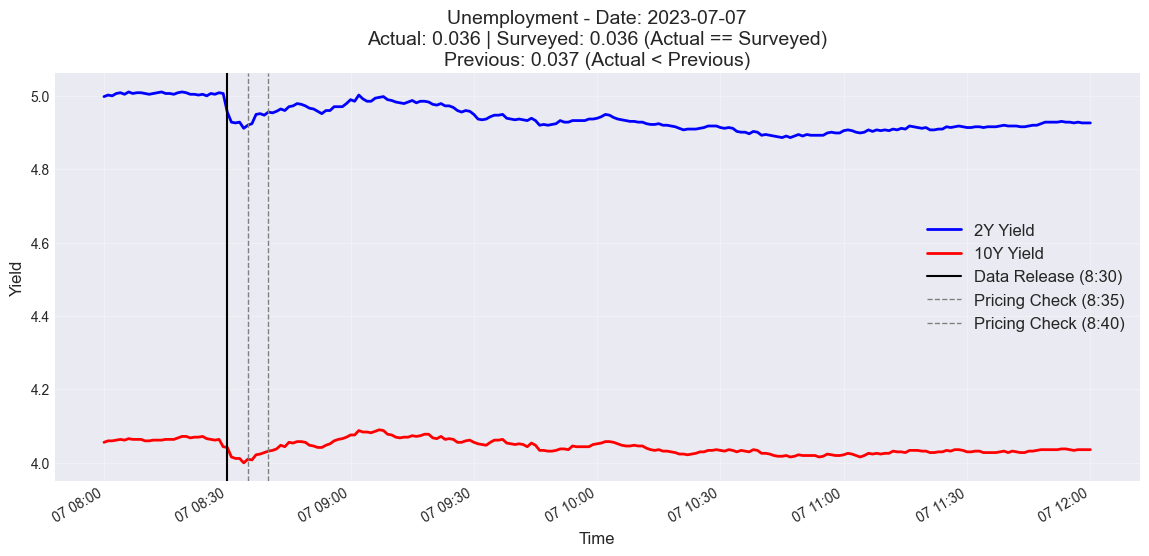

--------------------------------------------------


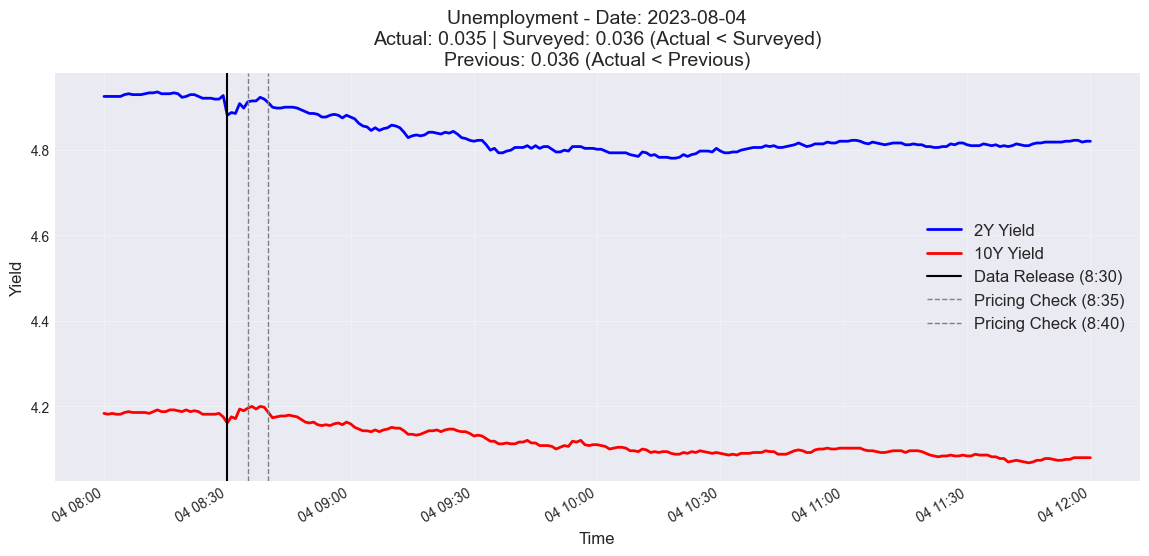

--------------------------------------------------


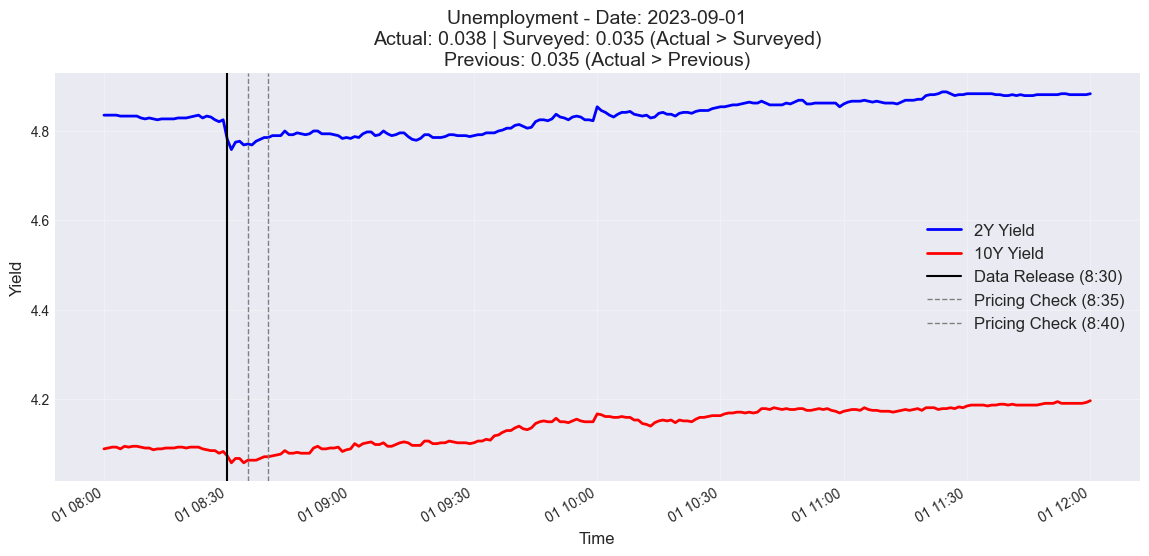

--------------------------------------------------


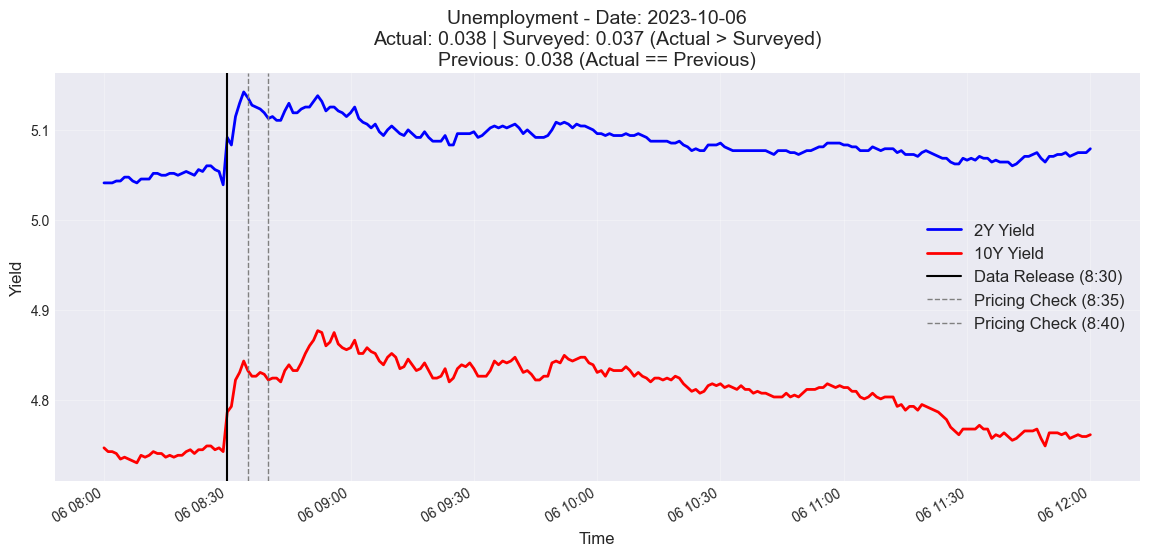

--------------------------------------------------


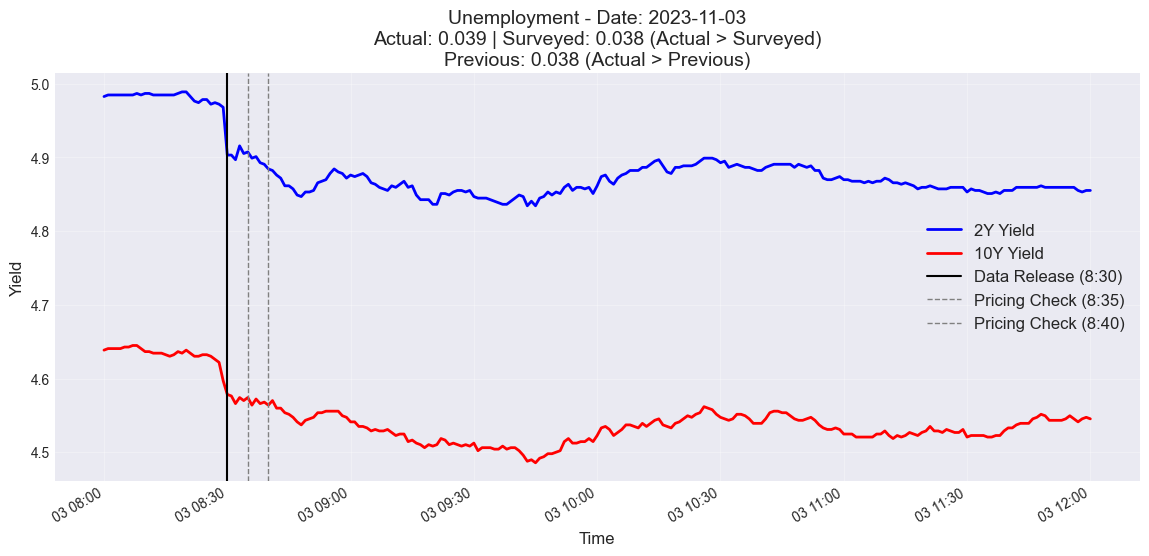

--------------------------------------------------


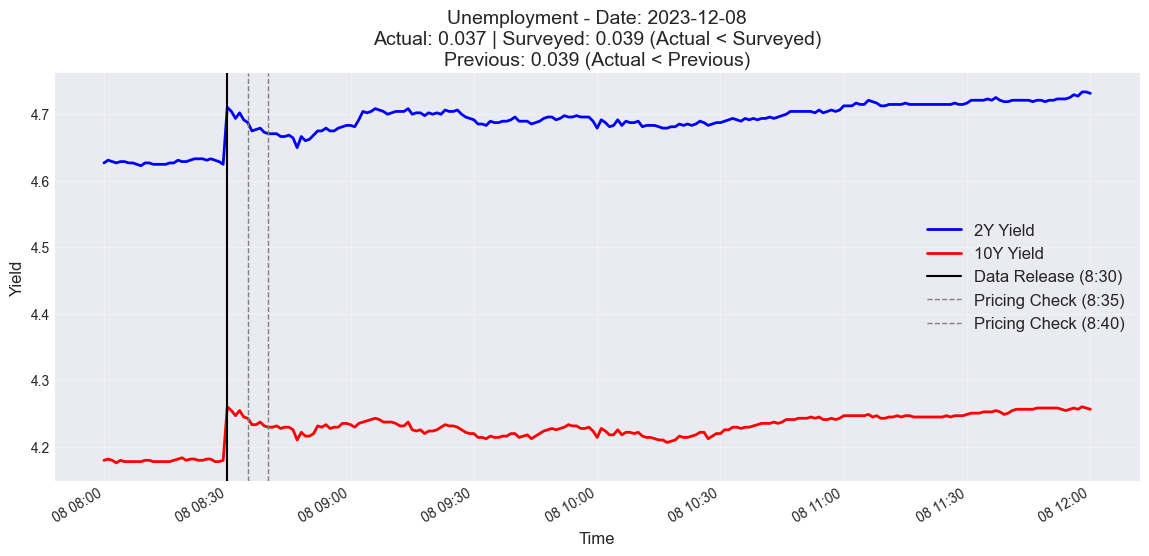

--------------------------------------------------


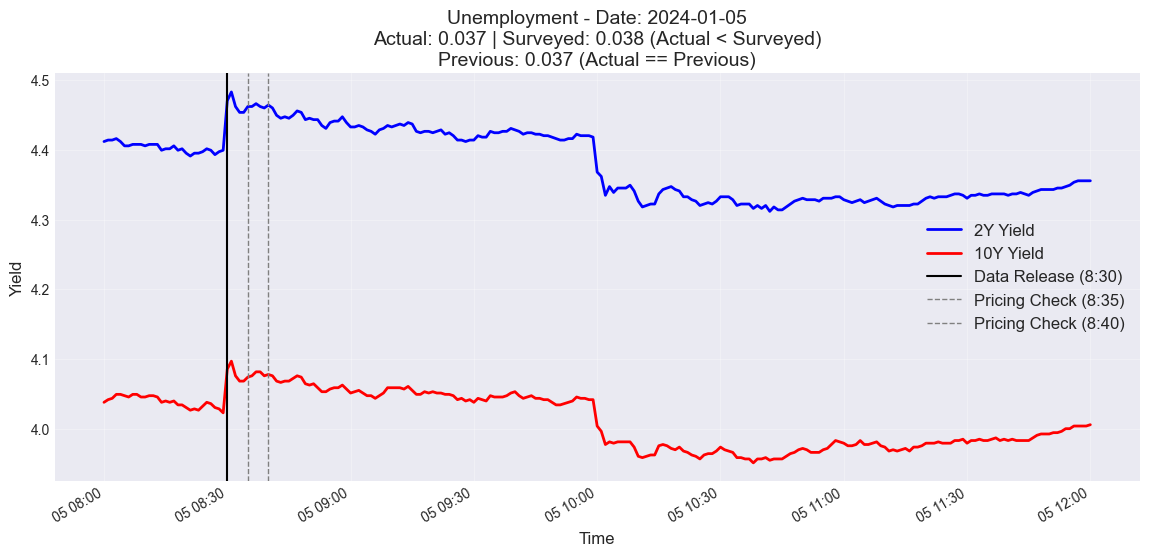

--------------------------------------------------


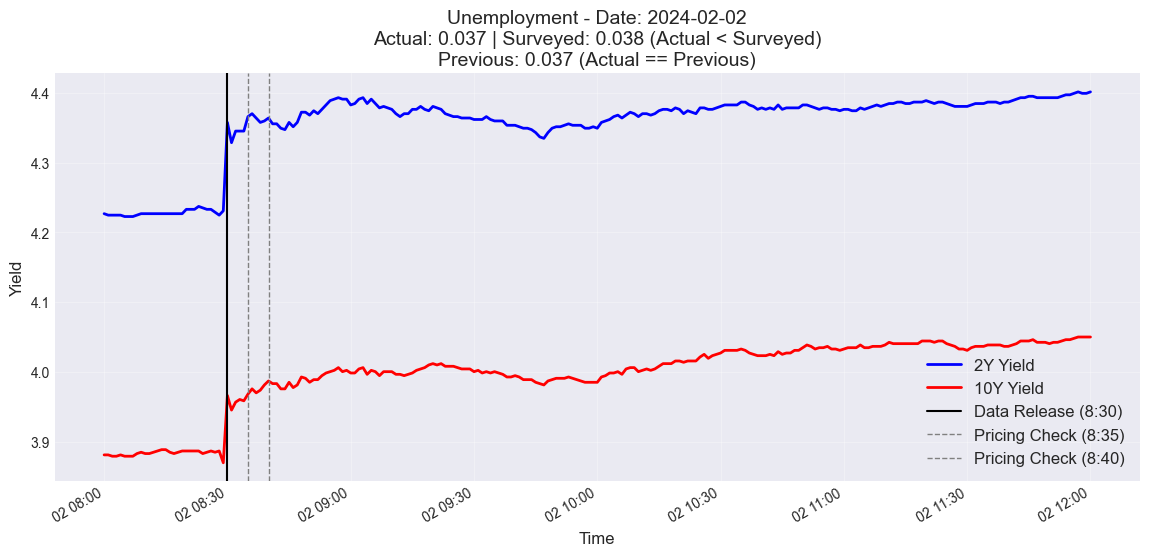

--------------------------------------------------


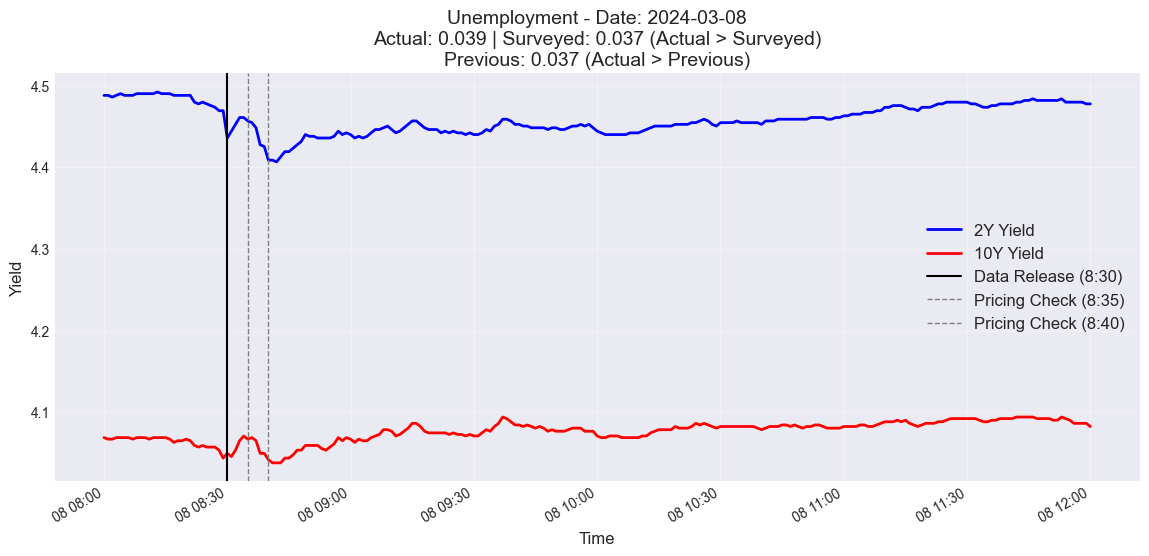

--------------------------------------------------


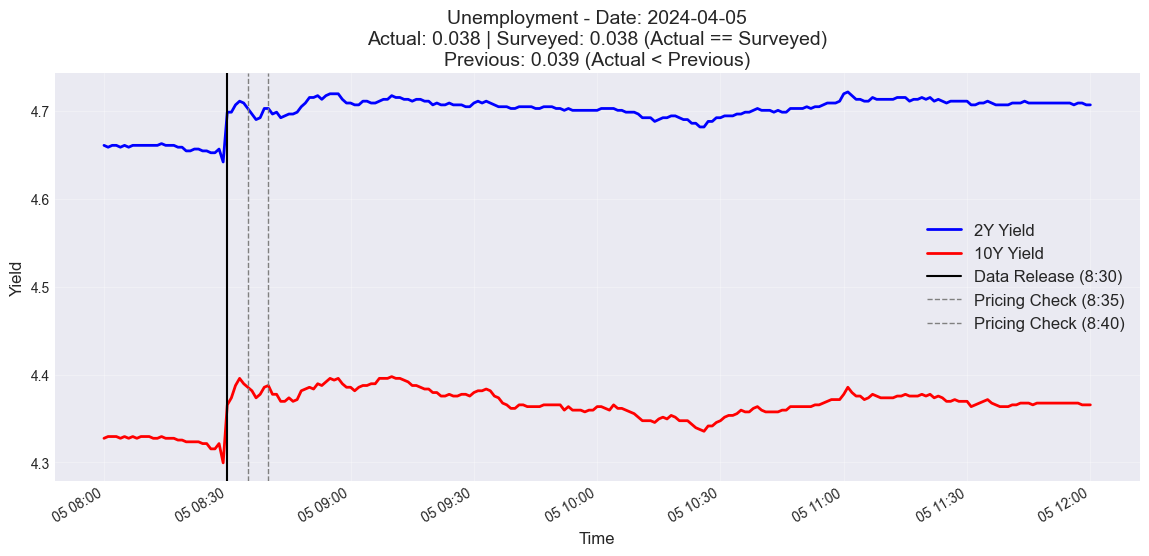

--------------------------------------------------


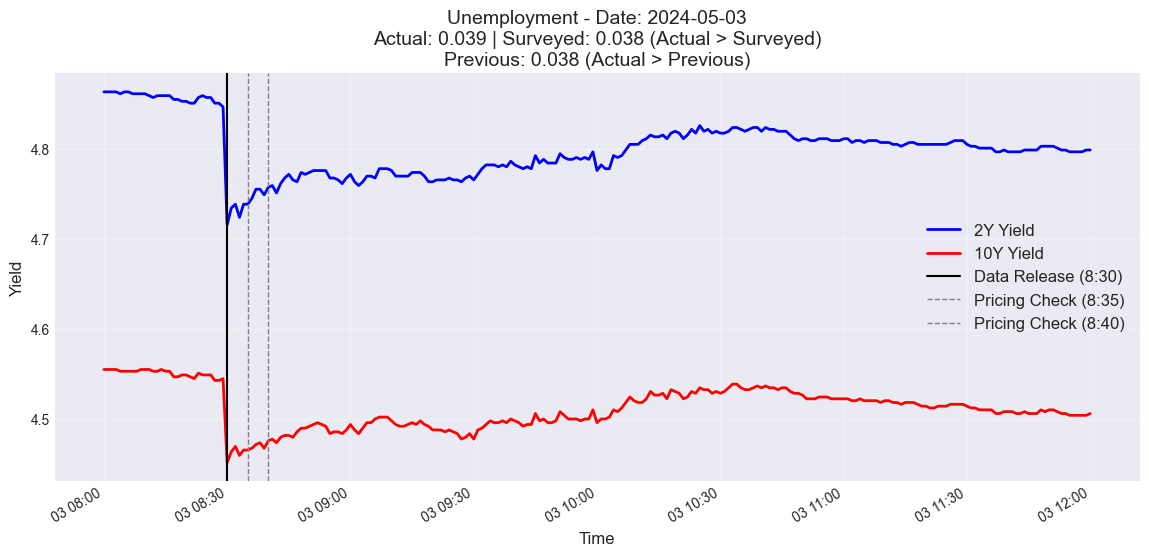

--------------------------------------------------


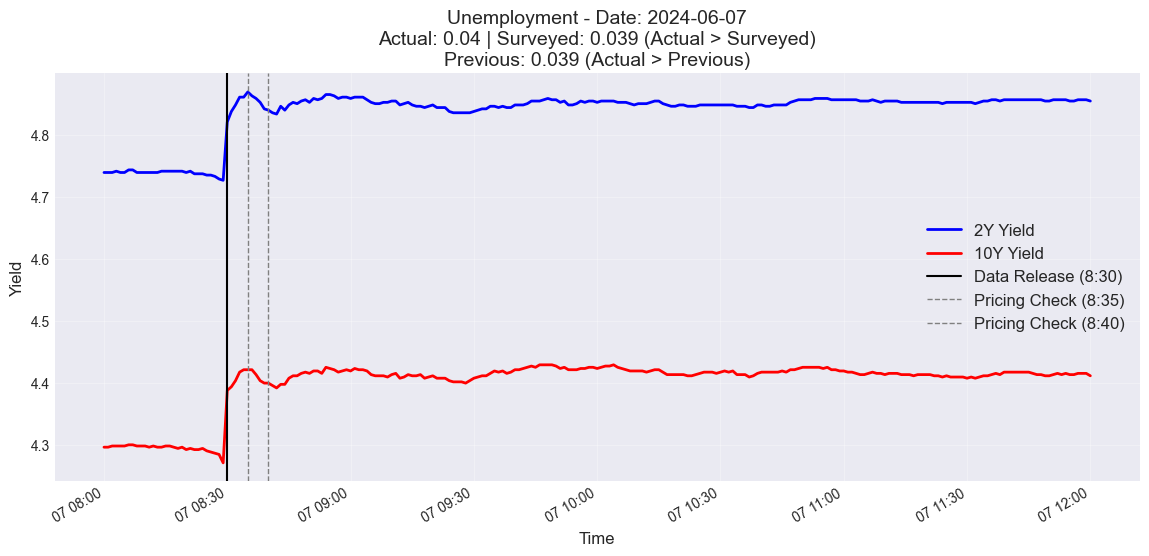

--------------------------------------------------


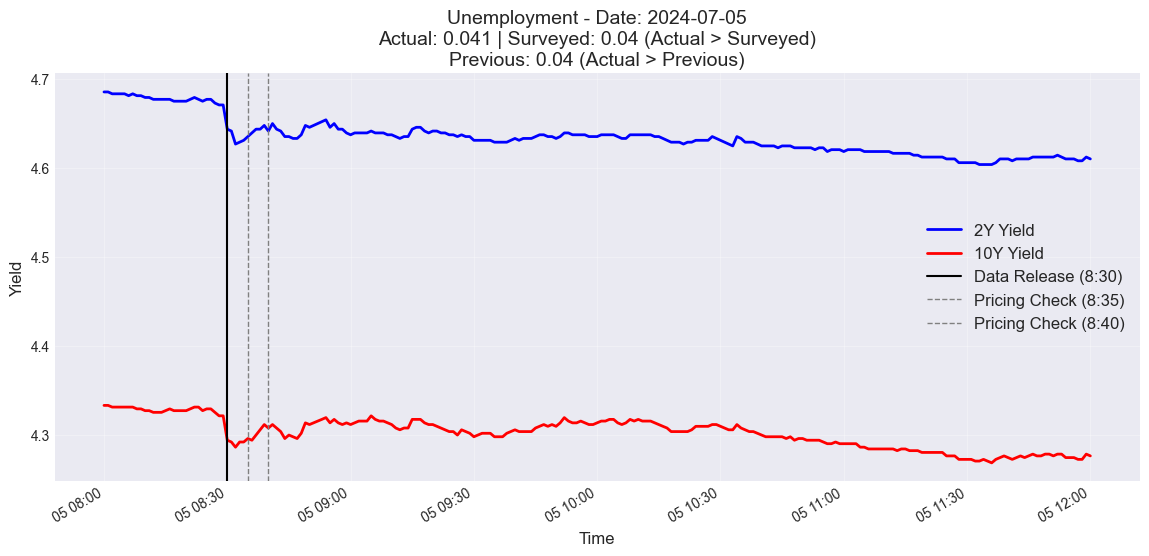

--------------------------------------------------


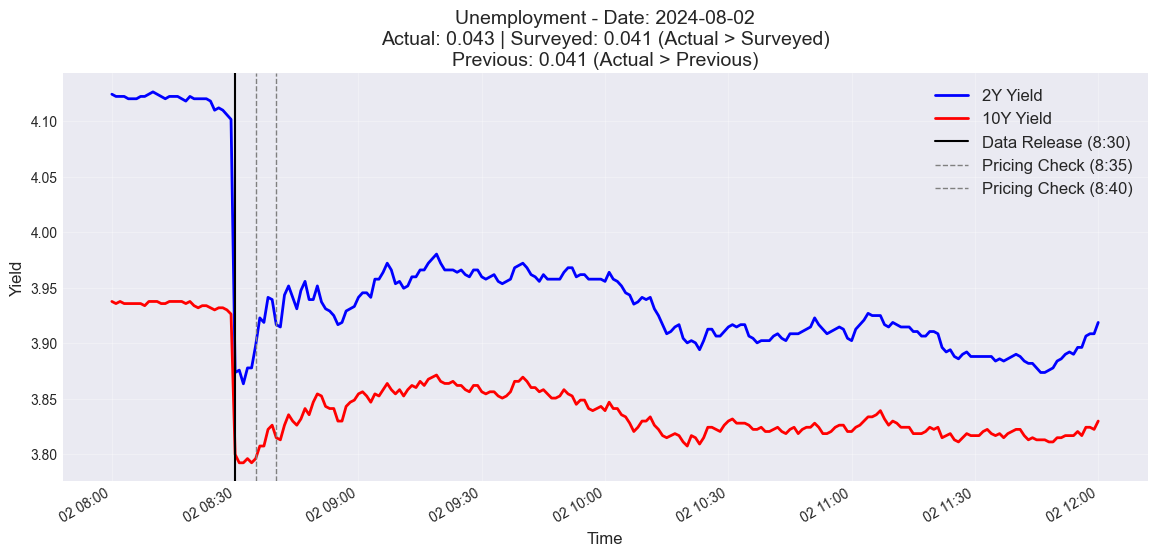

--------------------------------------------------


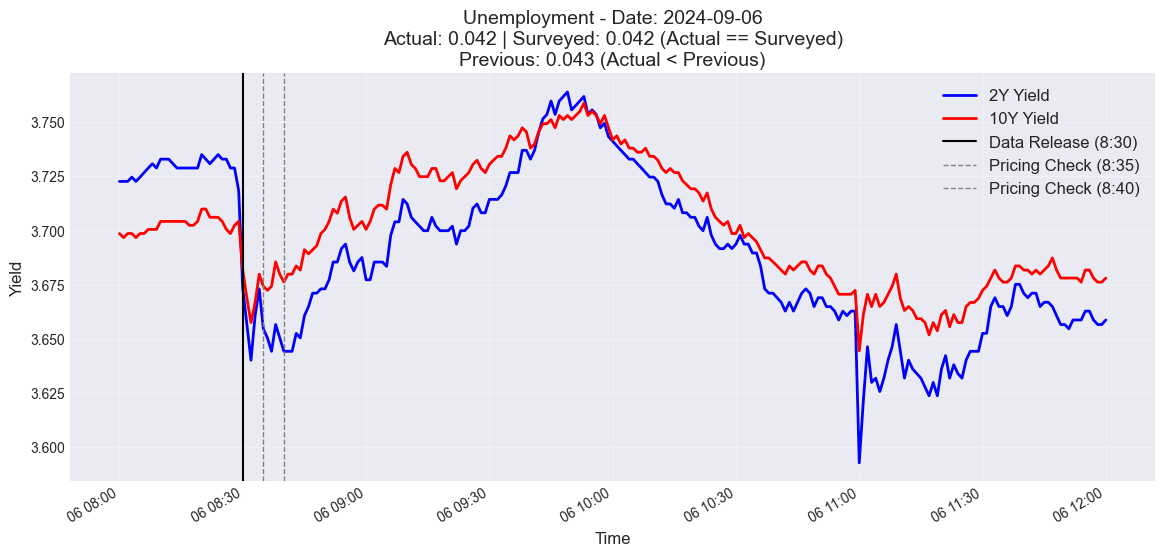

--------------------------------------------------


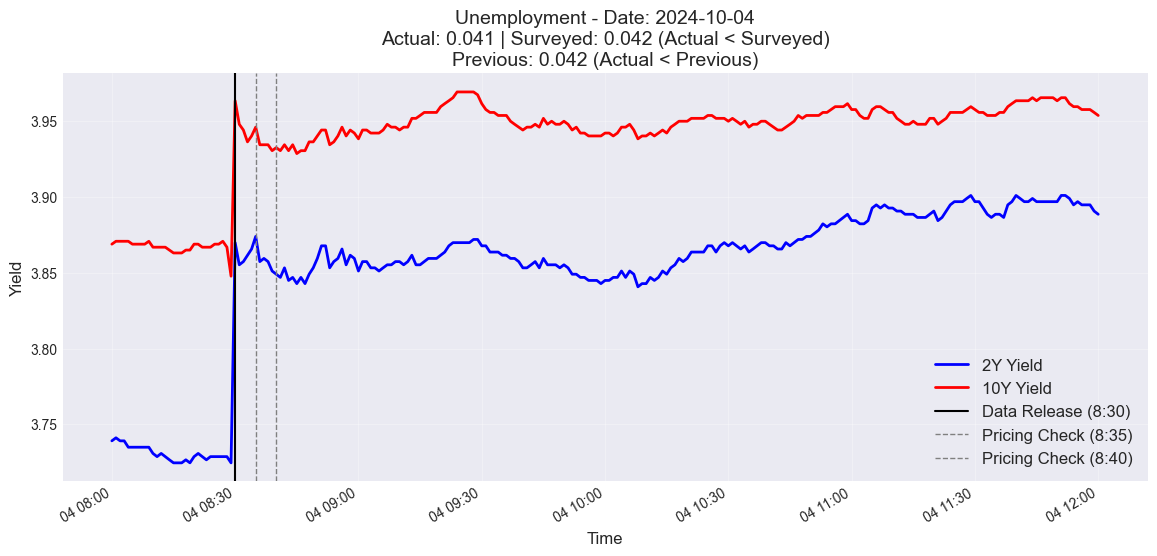

--------------------------------------------------


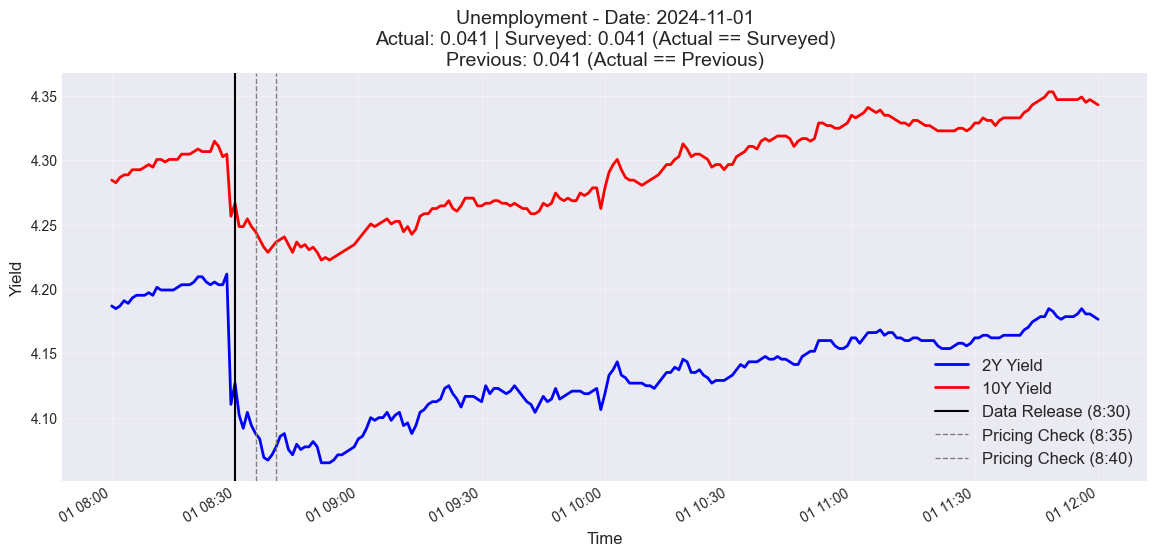

--------------------------------------------------


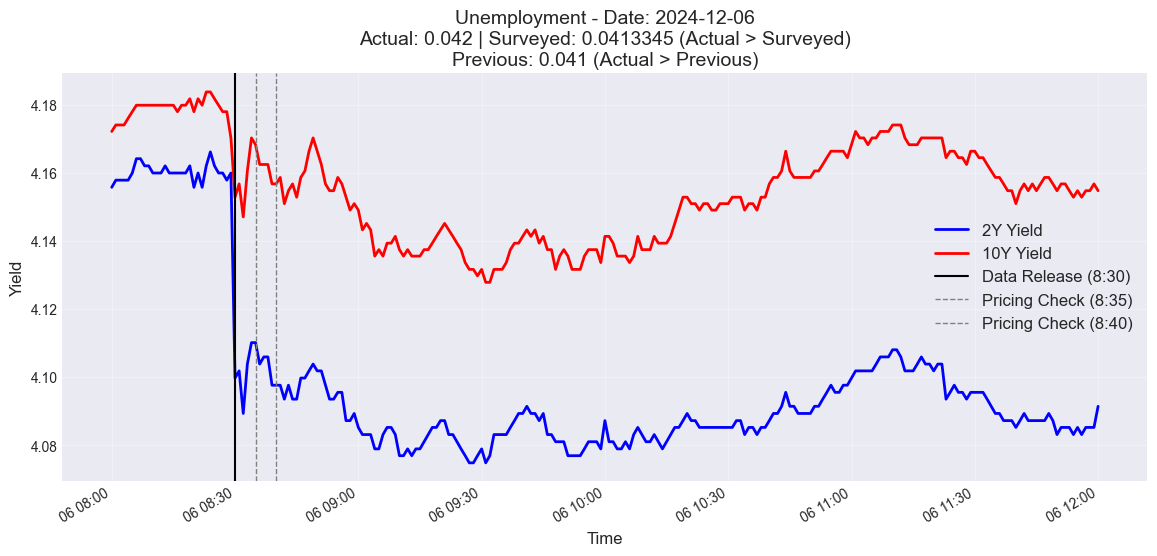

--------------------------------------------------


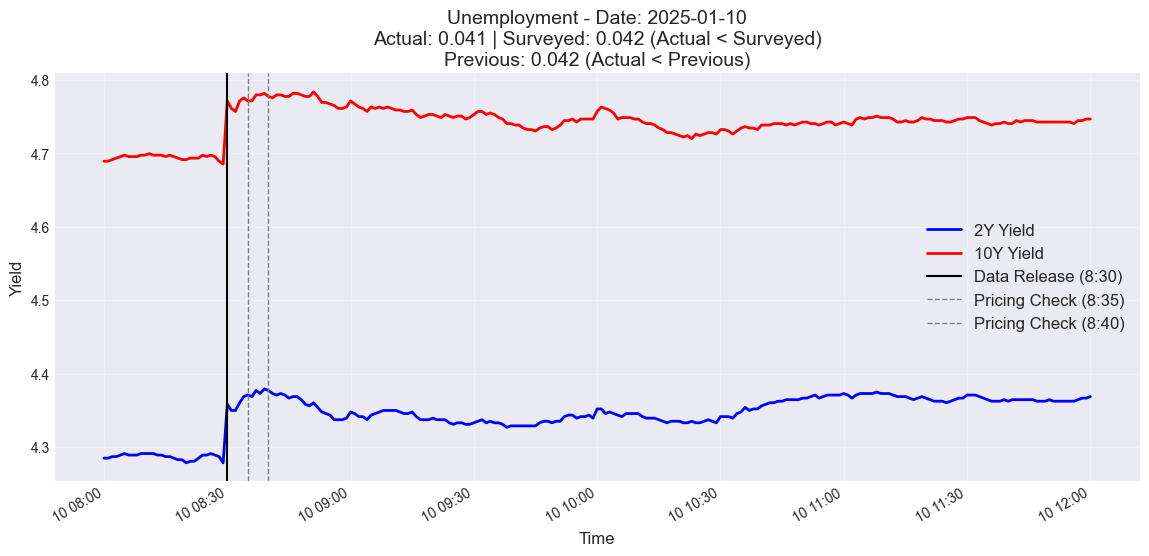

--------------------------------------------------


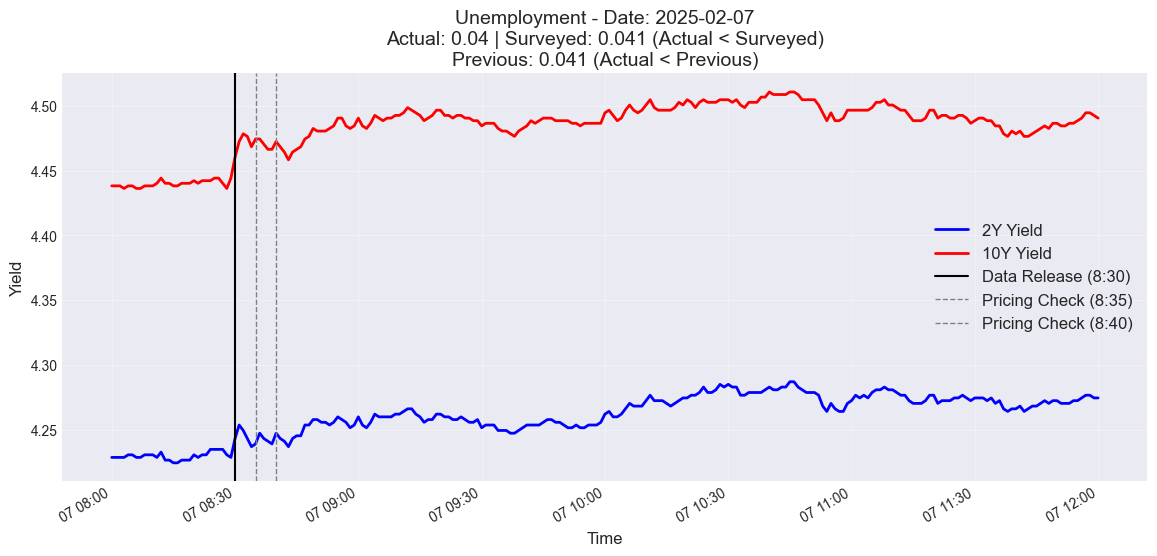

--------------------------------------------------


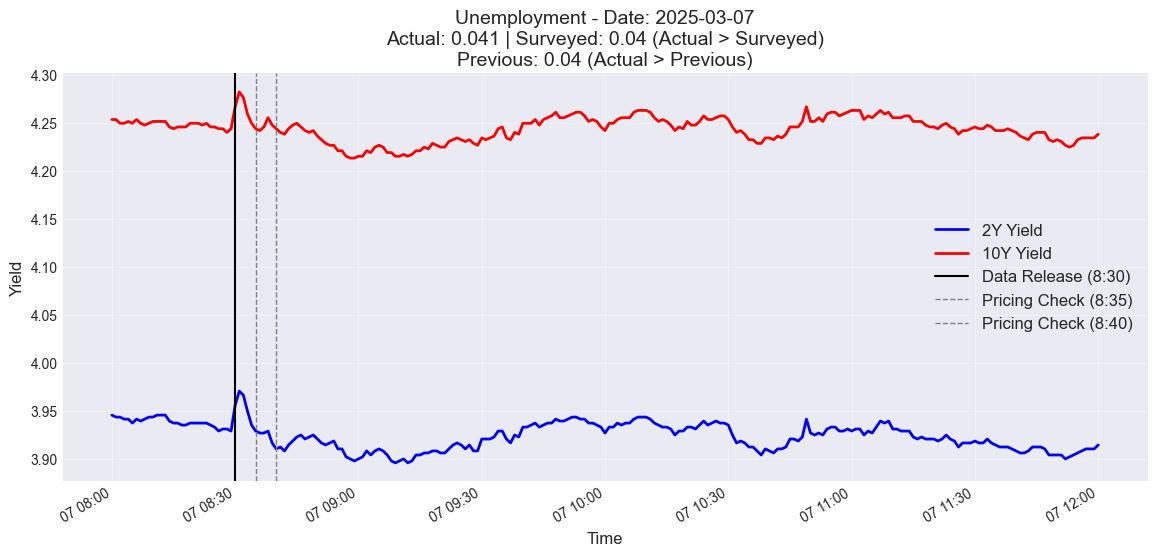

--------------------------------------------------


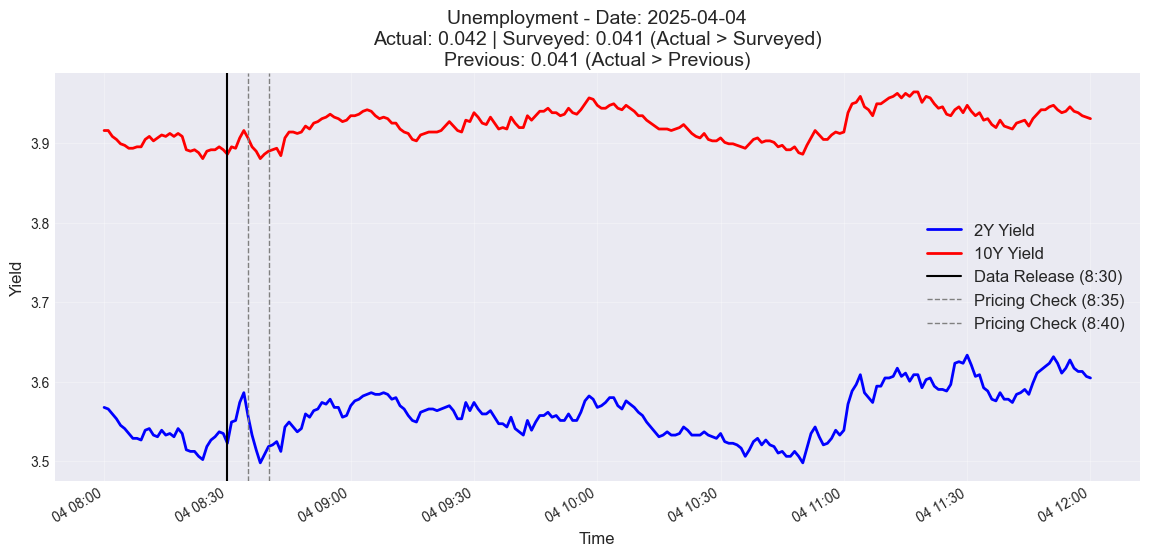

--------------------------------------------------


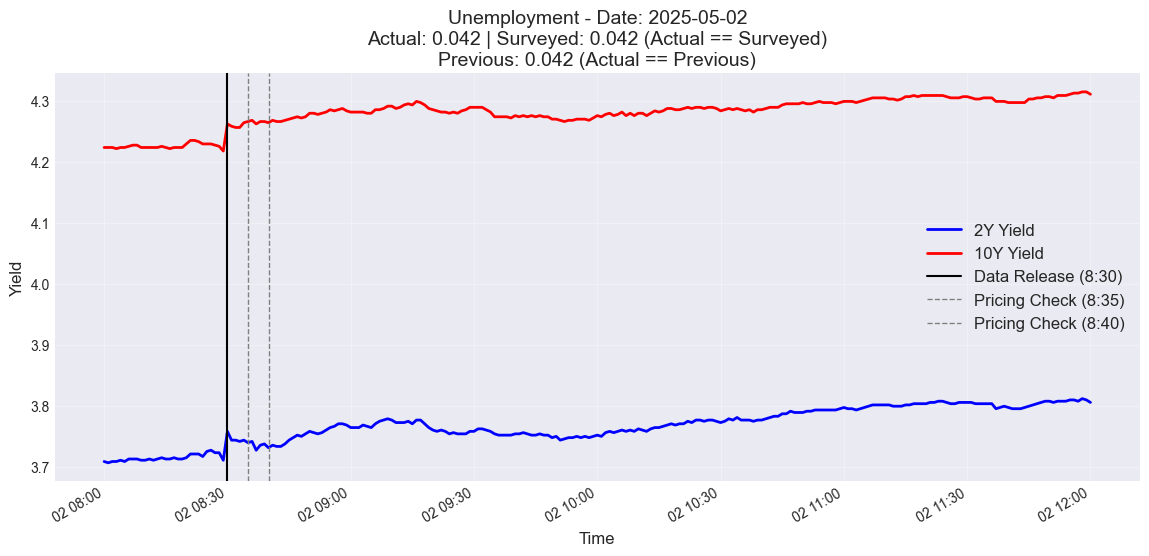

--------------------------------------------------


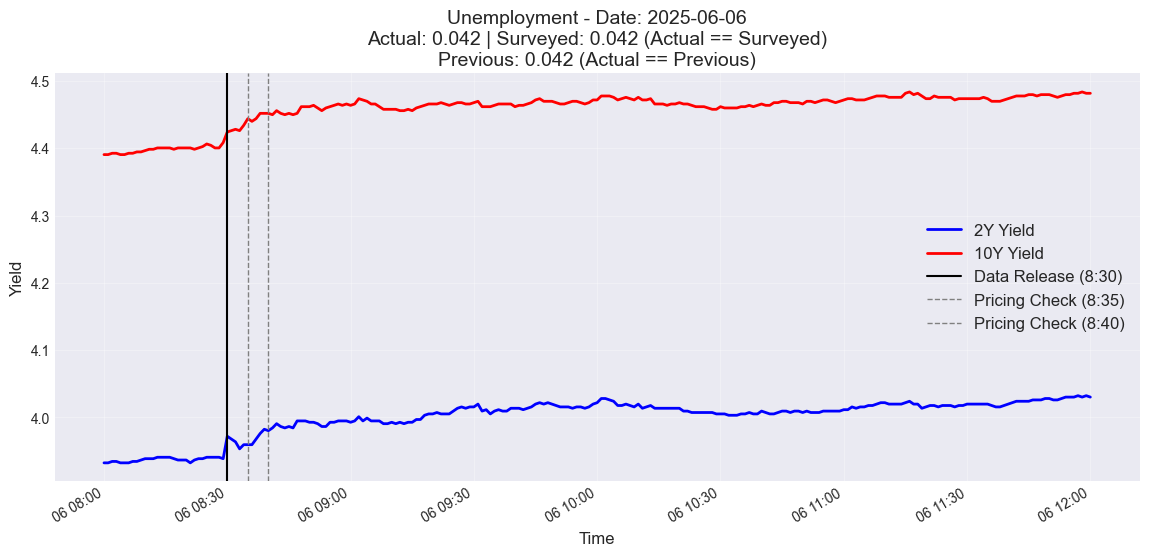

--------------------------------------------------


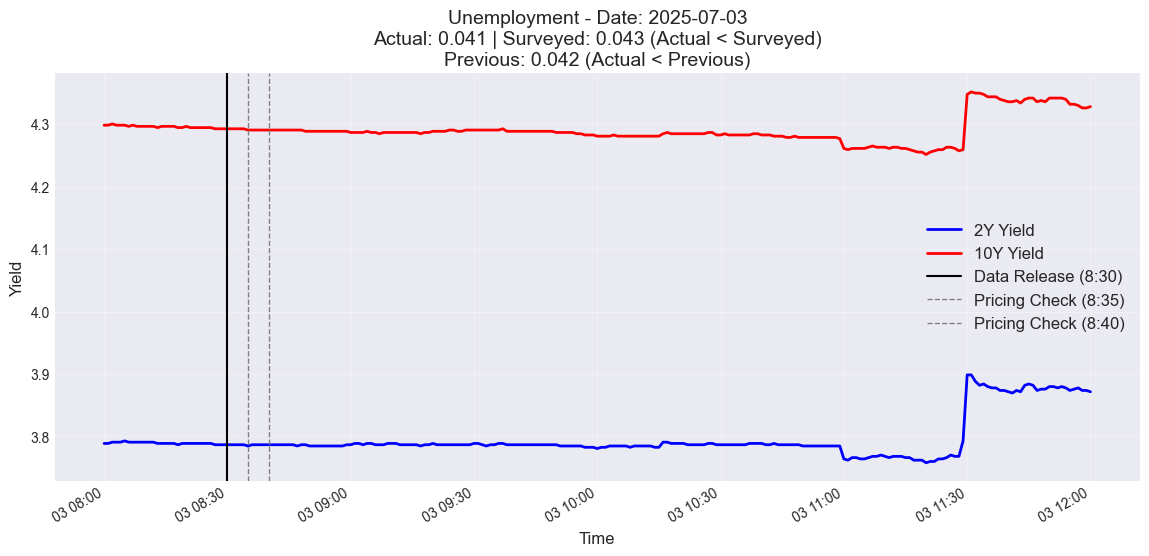

--------------------------------------------------


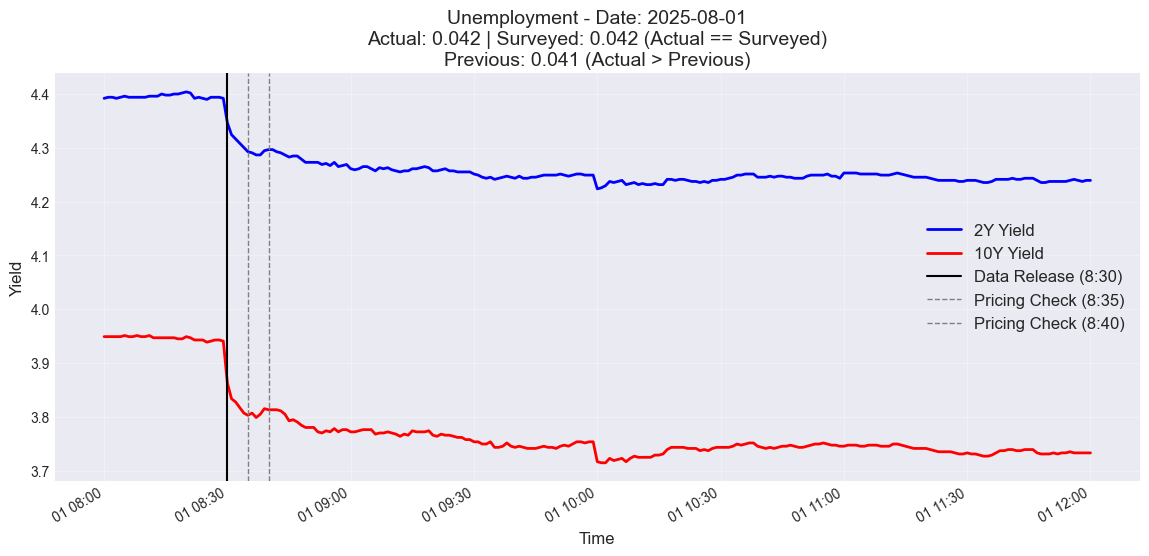

--------------------------------------------------


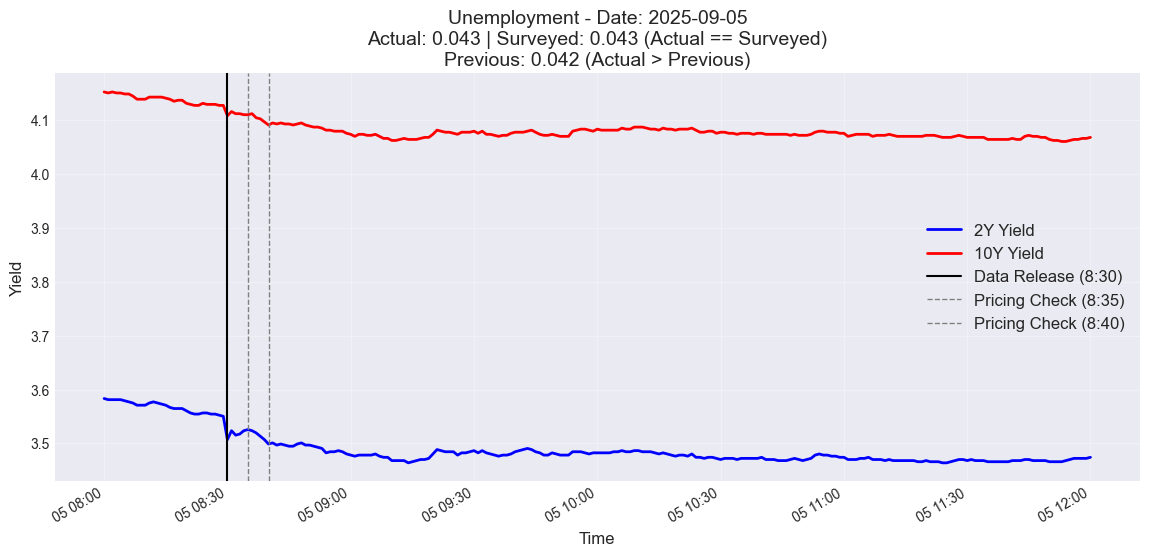

--------------------------------------------------


In [10]:
plot_event_data_until_noon('cleaned_unemployment_data.csv', 'Unemployment')